In [96]:
import numpy as np
from ezyrb import POD, RBF, Database, Linear, RegularGrid
from ezyrb import ReducedOrderModel as ROM
from scipy.interpolate import griddata
from smooth_POD_ROM.pre_processing import threshold
from scipy.ndimage import gaussian_filter

In [97]:
import matplotlib.pyplot as plt
import matplotlib as mpl
cmap = plt.cm.viridis_r
#cmap.set_over('red')

page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (page_width_in/2, page_width_in/3)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 25

8.030570172000001


In [65]:
timestep = 0.3
sgm = 4
n_x = n_y = 256
apply_threshold = False
rank = 80

In [66]:
def plot_dam_snapshot(ax, ss, X, Y, vmin=0, vmax=1):
    cmap = plt.cm.viridis_r
    #cmap.set_under('C3')
    x = np.unique(X)
    dx = x[1]-x[0]
    y = np.unique(Y)
    dx = y[1]-y[0]
    extent = (np.min(x)-dx/2, np.max(x)+dx/2, np.min(y)-dx/2, np.max(y)+dx/2)
    cs = ax.imshow(ss.T, origin="lower", interpolation="nearest", extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
    return cs

In [5]:
pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/data/damBreak_alpha/"
p_train = np.genfromtxt(pth+"p_train.npy")
p_test = np.genfromtxt(pth+"p_test.npy")
p_val = np.genfromtxt(pth+"p_val.npy")
points = np.genfromtxt(pth+"points.npy")

u_train = np.genfromtxt(pth+"t{:.2f}_u_train.npy".format(timestep))
u_test = np.genfromtxt(pth+"t{:.2f}_u_test.npy".format(timestep))
u_val = np.genfromtxt(pth+"t{:.2f}_u_val.npy".format(timestep))

In [128]:
def local_mass_conservation(data, window_size, chunk_size):
    sz = window_size//2
    m, n = data.shape
    data_tmp = data.copy()

    #data_pp = np.zeros_like(data_t)
    #n_evals = np.zeros_like(data_t)
    vmax = 0.8
    is_interface0 = (1e-4 < data_tmp) & (data_tmp < 1-1e-4)
    data_tmp[data_tmp<1e-4] = 0
    data_tmp[data_tmp>1-1e-4] = 1
    
    keep_looping = True
    while keep_looping:
        is_interface0 = (1e-4 < data_tmp) & (data_tmp < 1-1e-4)
        n0 = np.sum(data_tmp<1e-4)
        n1 = np.sum(data_tmp>1-1e-4)

        i1D = np.argsort(data_tmp.ravel())  # expensive!  # *(1+np.random.rand(*data_tmp.ravel().shape)*1e-4)
        i1D = i1D[n0:-n1]
        ii, jj = np.unravel_index(i1D, data.shape)
        #print(len(ii))

        for i, j in zip(ii[:chunk_size], jj[:chunk_size]):
            s1 = np.clip(i-sz-1, 0, m)
            e1 = np.clip(i+sz, 0, m)
            s2 = np.clip(j-sz-1, 0, n)
            e2 = np.clip(j+sz, 0, n)
            val = data_tmp[i, j]
            if val < vmax:  # might happen when mass from neighboring cells got moved
                window = data_tmp[s1:e1, s2:e2]
                m1 = np.sum(data_tmp)
                mask_w = (val < window) & (window < 1-1e-4)
                if np.any(mask_w):
                    window[mask_w] = window[mask_w] / np.sum(window[mask_w]) * (np.sum(window[mask_w])+val)
                    data_tmp[i, j] = 0.0

                    m2 = np.sum(data_tmp)
                    if np.abs(m2-m1)> 1e-4:
                        print(val, np.sum(window[mask_w]), np.sum(mask_w))

                    is_too_much = window > 1.0
                    data_tmp[i, j] = np.sum((window-1)[is_too_much])
                    window[is_too_much] = 1.0

                    m3 = np.sum(data_tmp)
                    if np.abs(m3-m2)> 1e-4:
                        print(val, data_tmp[i, j], np.sum(is_too_much), "asdasdsa")
        is_interface1 = (1e-4 < data_tmp) & (data_tmp < 1-1e-4)
        if np.sum(is_interface1) == np.sum(is_interface0):
            keep_looping = False
    return data_tmp

# gridding

In [67]:
x = np.linspace(0, 0.58399999, n_x, endpoint=True)
y = np.linspace(0, 0.58399999, n_y, endpoint=True)
X, Y = np.meshgrid(x, y, indexing="ij")
is_wall = (0.292 <= X) & (X <= 0.316) & (Y <= 0.048)

u_train_grid = np.empty((n_x*n_y, u_train.shape[1]))
u_test_grid = np.empty((n_x*n_y, u_test.shape[1]))
u_val_grid = np.empty((n_x*n_y, u_val.shape[1]))

for u_set, u_set_grid in zip([u_train, u_test, u_val], [u_train_grid, u_test_grid, u_val_grid]):
    gridded = griddata(points[:, :2], u_set, (X, Y), method="linear")
    if apply_threshold:
        gridded = threshold(gridded)
    for j in range(u_set.shape[1]):
        gridded[is_wall, j] = 0.5
        u_set_grid[:, j] = gridded[:, :, j].ravel()


0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 

# standard ROM


In [98]:
reg = RegularGrid()
pod = POD(rank=rank)
db = Database(p_train, u_train_grid.T)
rom = ROM(db, pod, reg)
rom.fit()
u_ROM = rom.predict(p_val).T
for j in range(len(p_val)):
    if apply_threshold:
        u_ROM[:, j] = threshold(u_ROM[:, j])
    rmw = u_ROM[:, j].reshape(n_x, n_y)
    rmw[is_wall] = 0.5
    u_ROM[:, j] = rmw.ravel()

# s ROM

In [124]:
sgm = 7

In [125]:
u_train_smooth = np.zeros_like(u_train_grid)

for j in range(u_train_grid.shape[1]):
    ss2D = u_train_grid[:, j].reshape(n_x, n_y)
    u_train_smooth[:, j] = gaussian_filter(ss2D, sigma=sgm, truncate=10).ravel()

In [126]:
reg = RegularGrid()
pod = POD(rank=rank)
db = Database(p_train, u_train_smooth.T)
srom = ROM(db, pod, reg)
srom.fit()

u_sROM = srom.predict(p_val).T

# sROMs

0


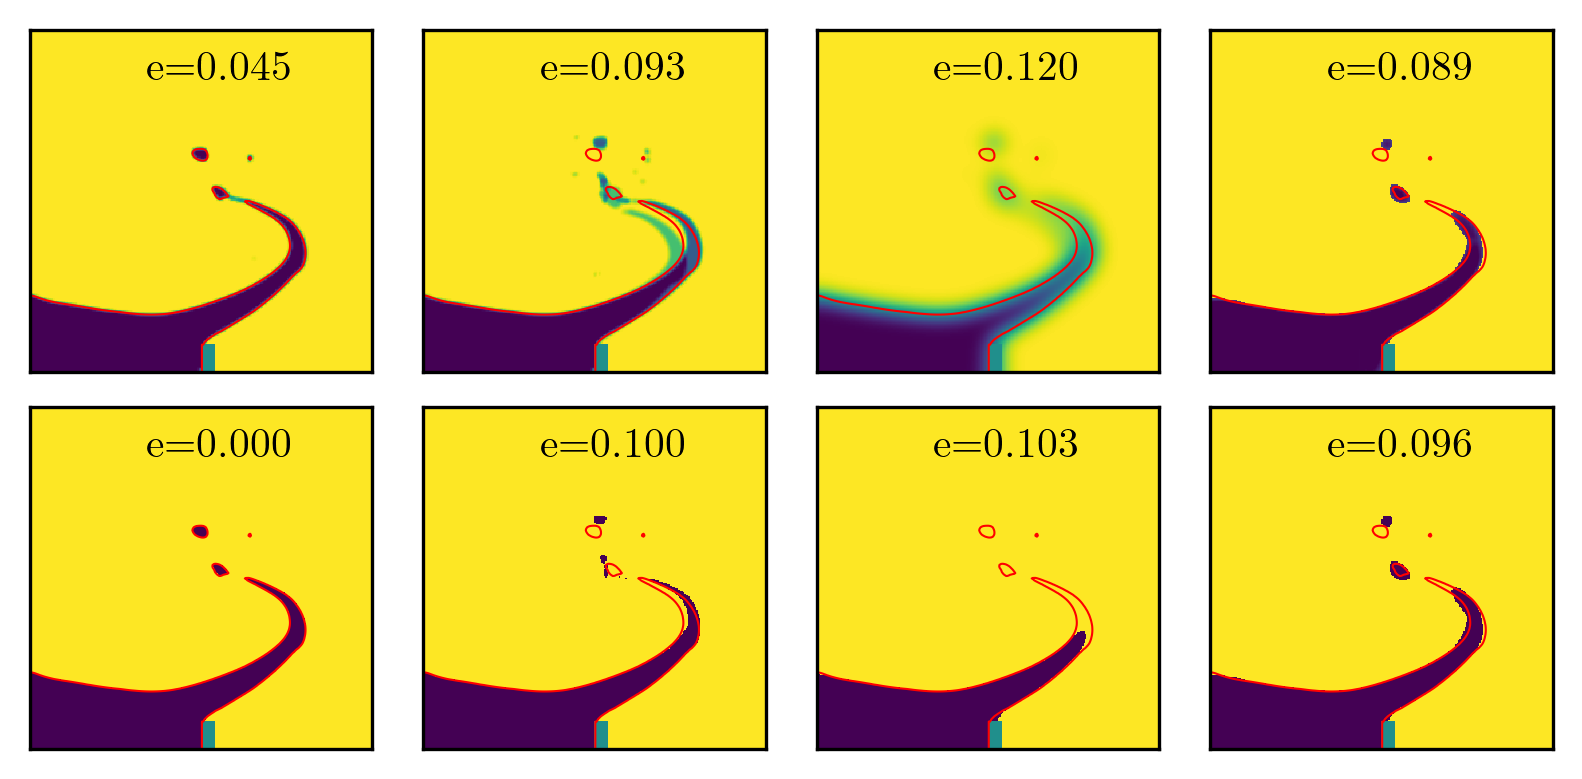

1


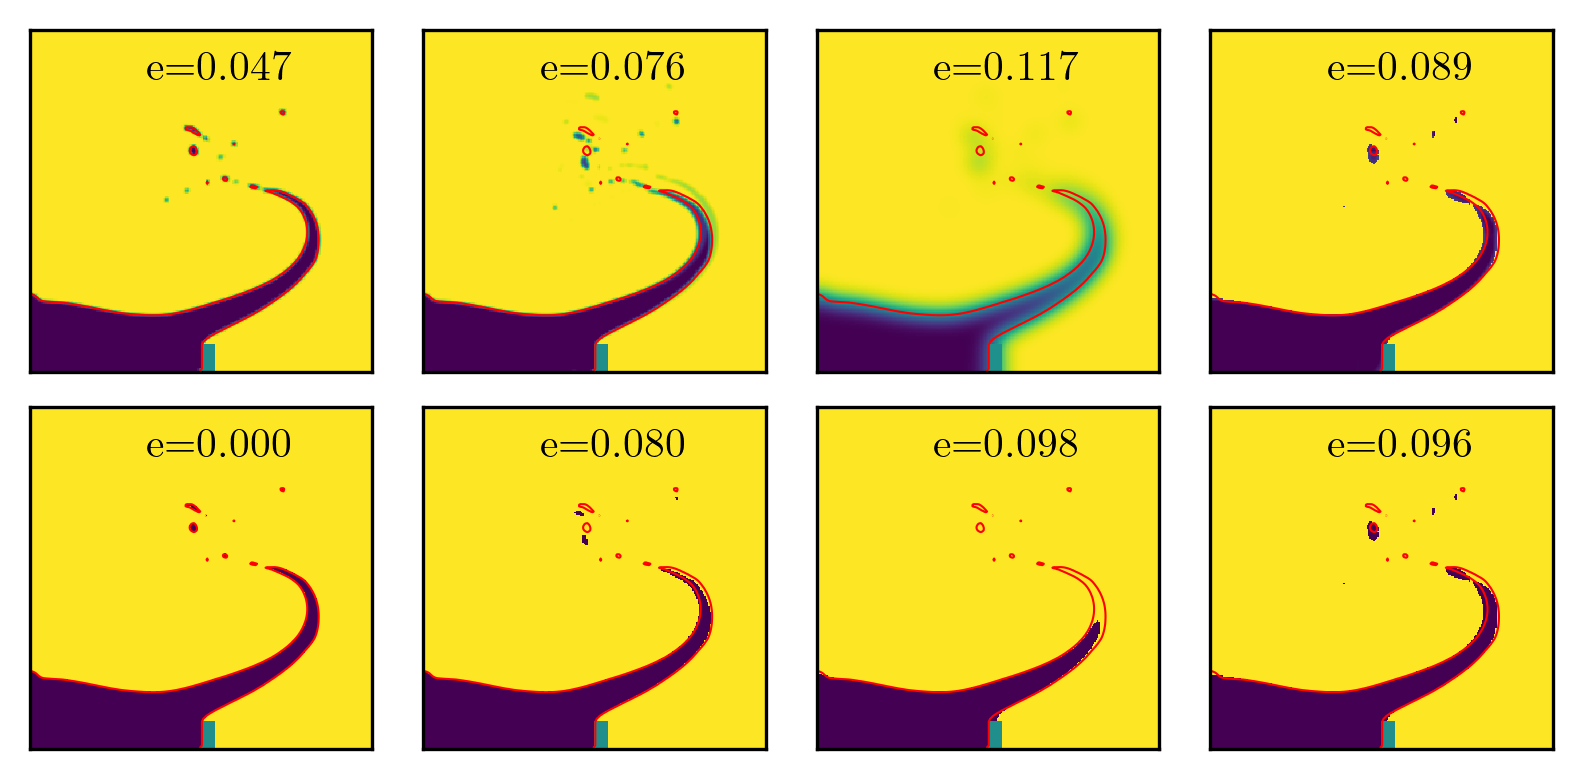

2


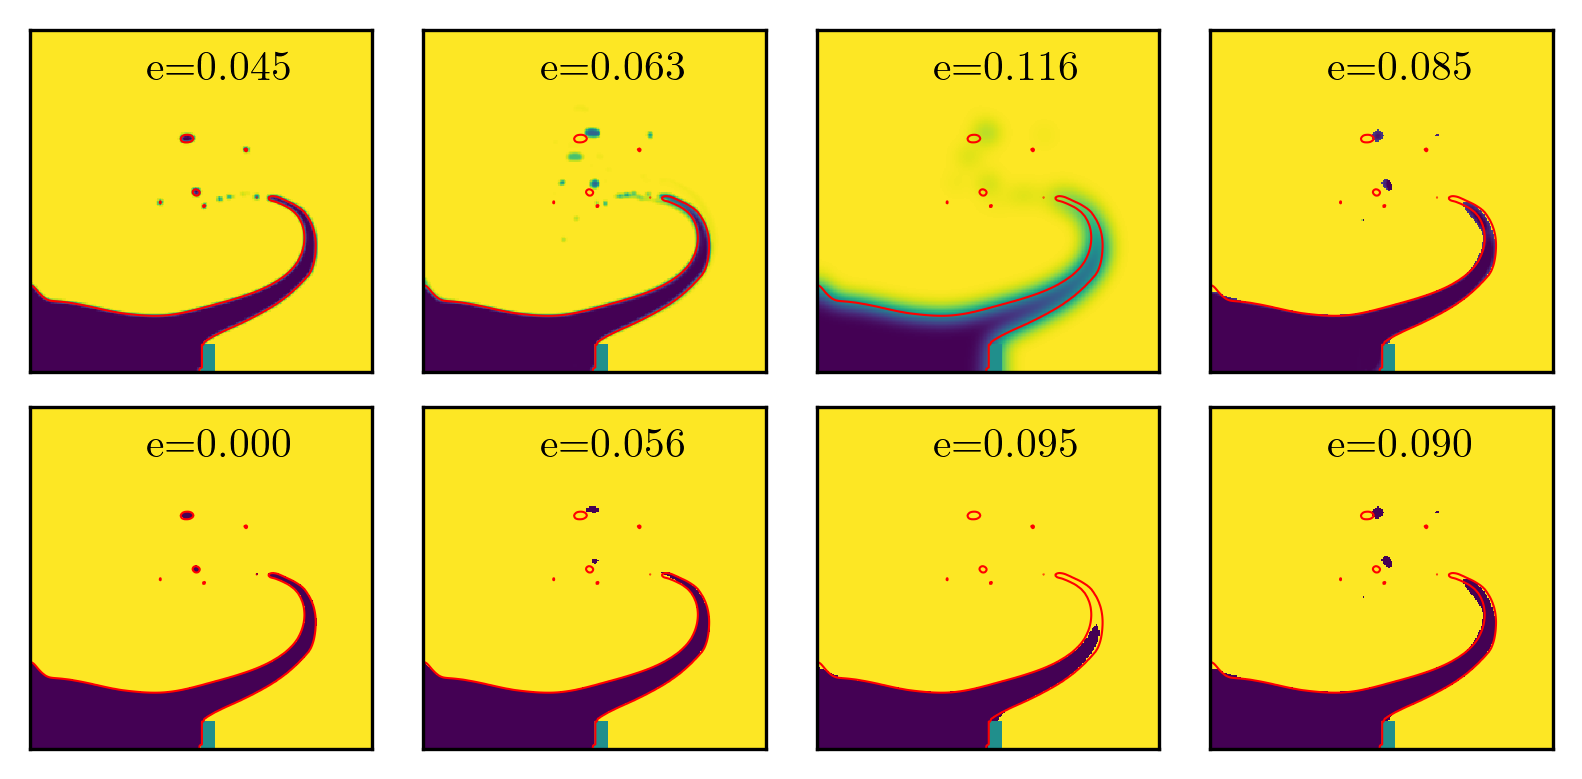

3


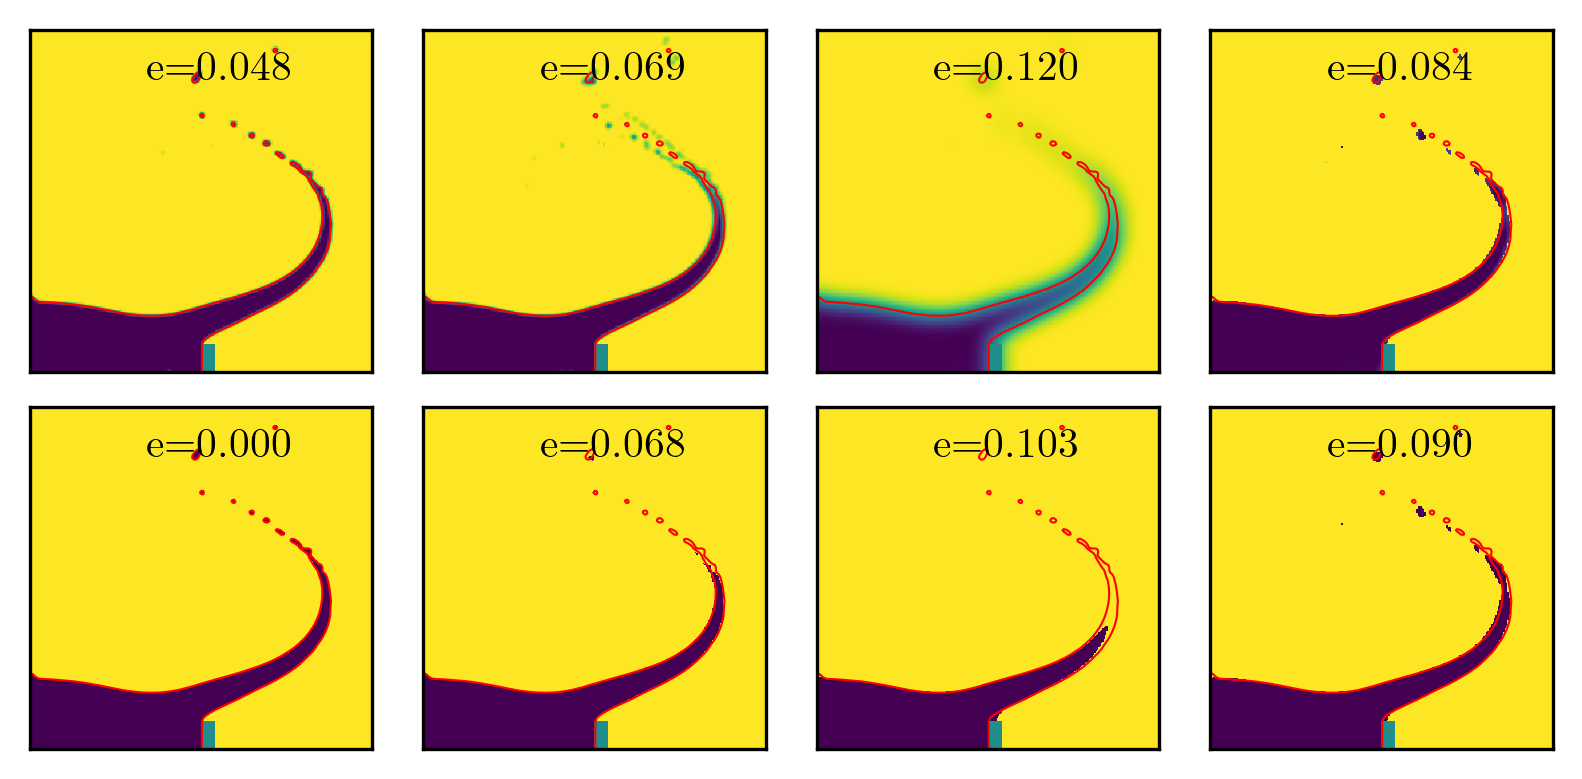

4


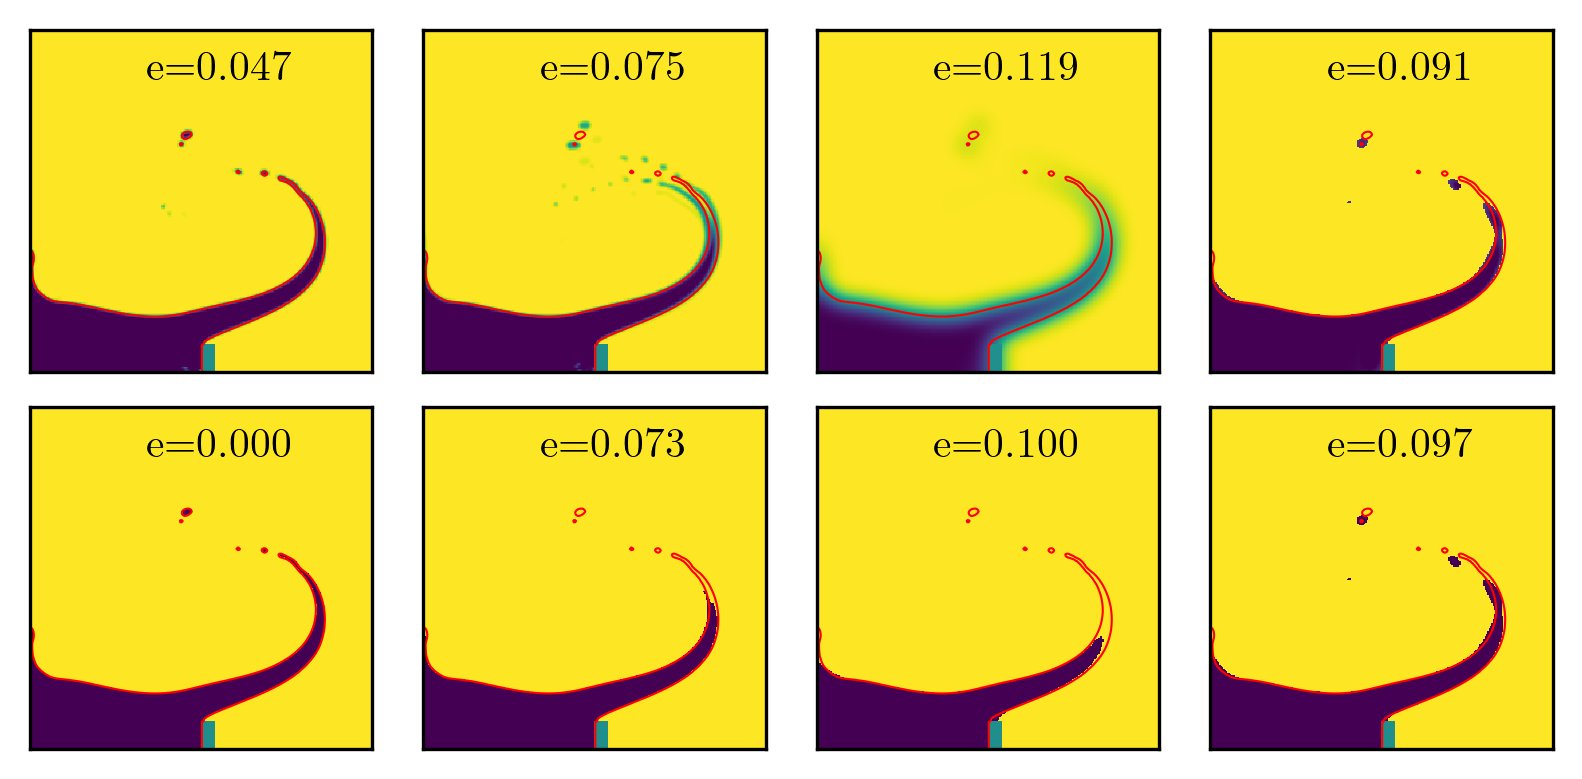

5


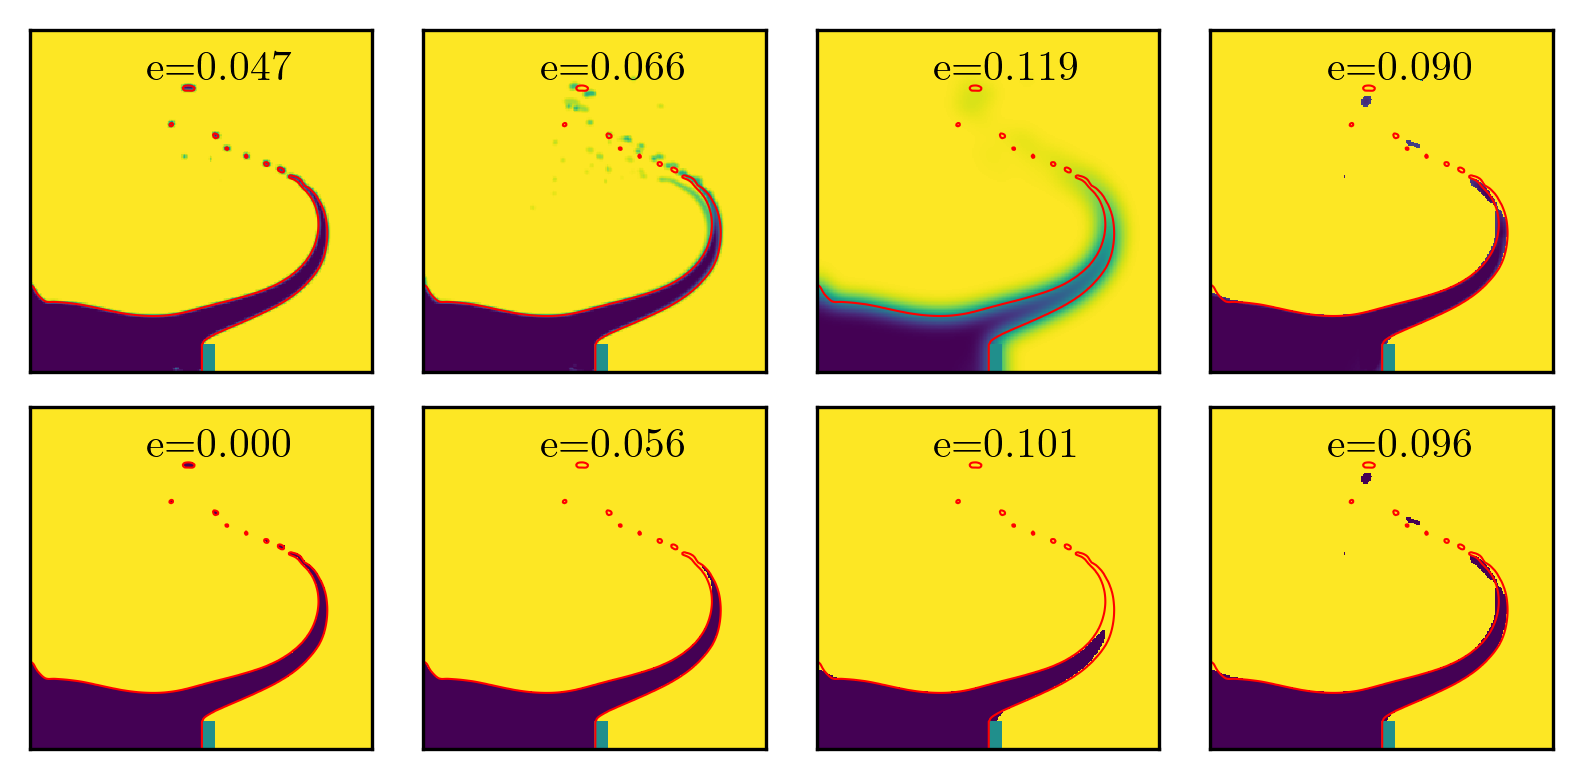

6


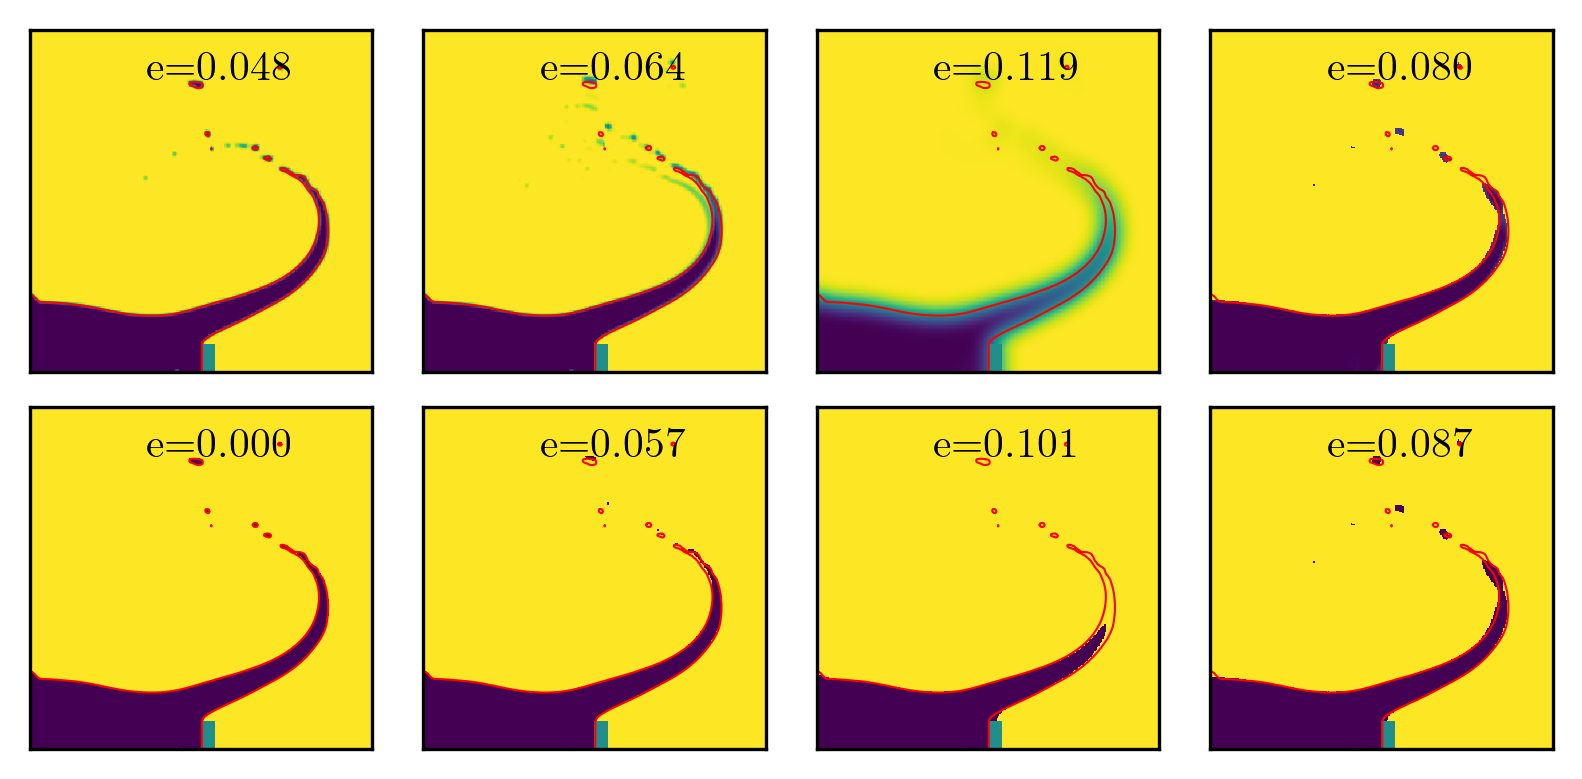

7


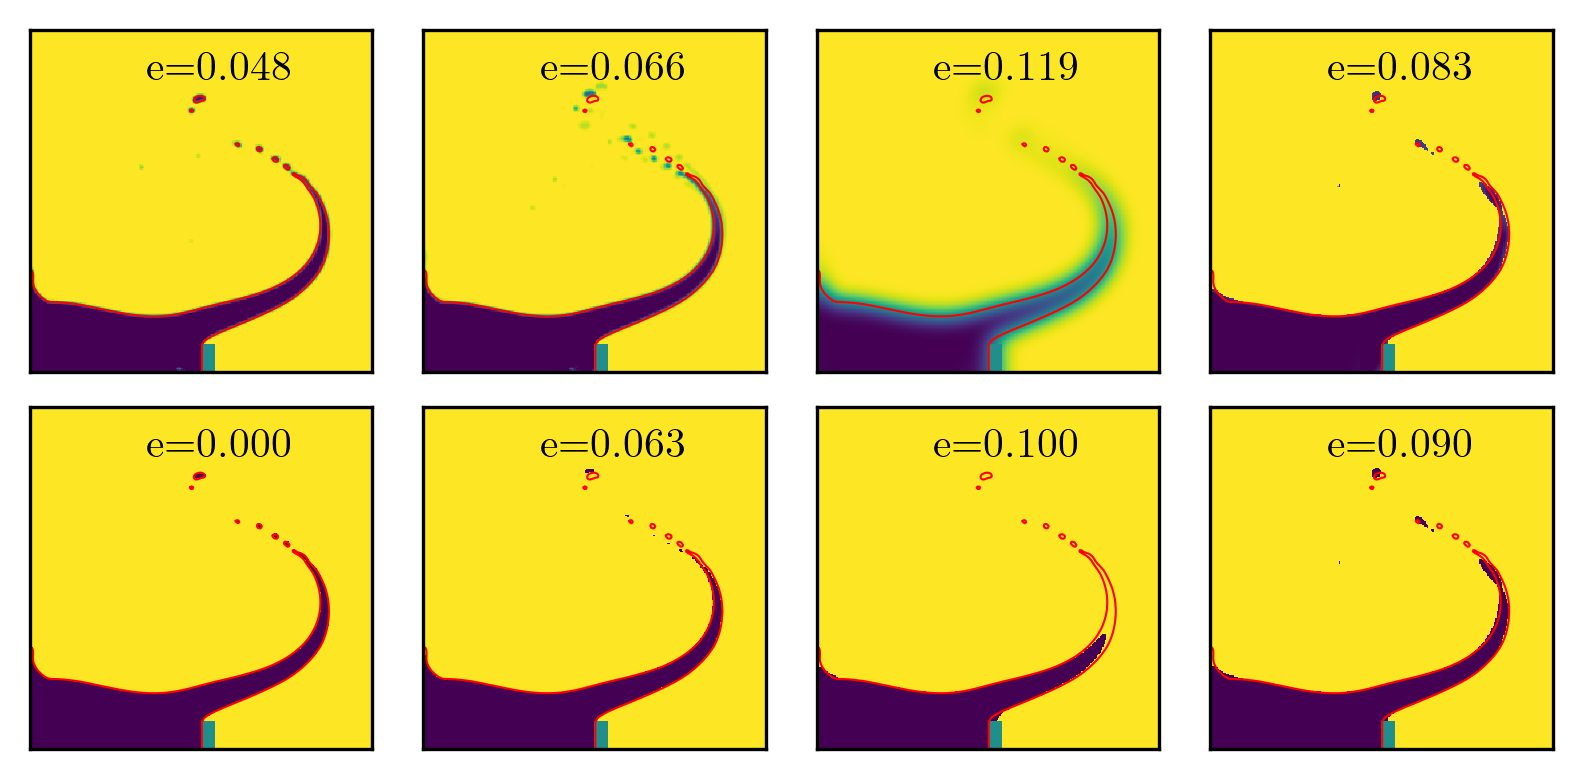

8


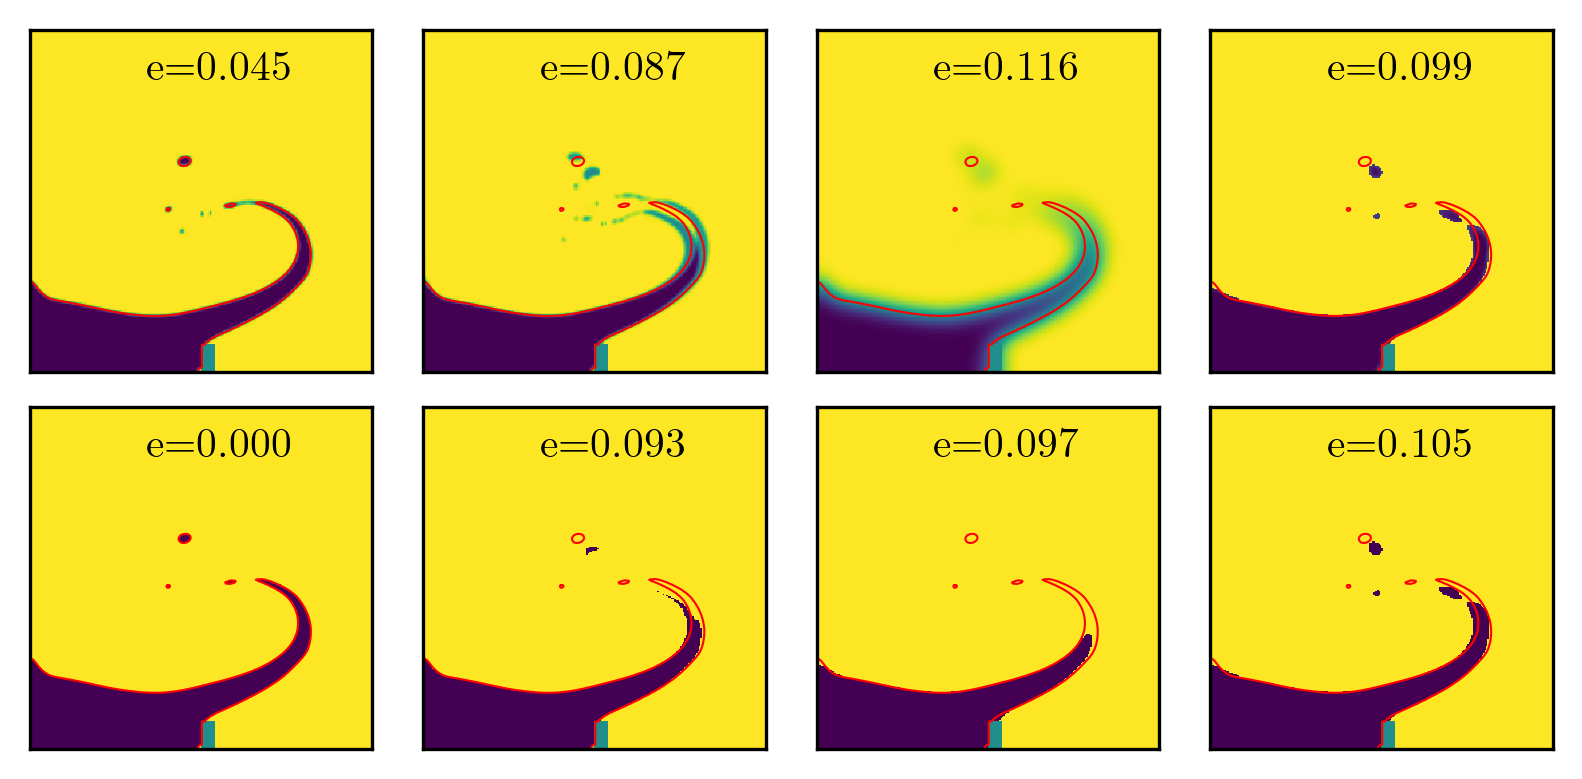

9


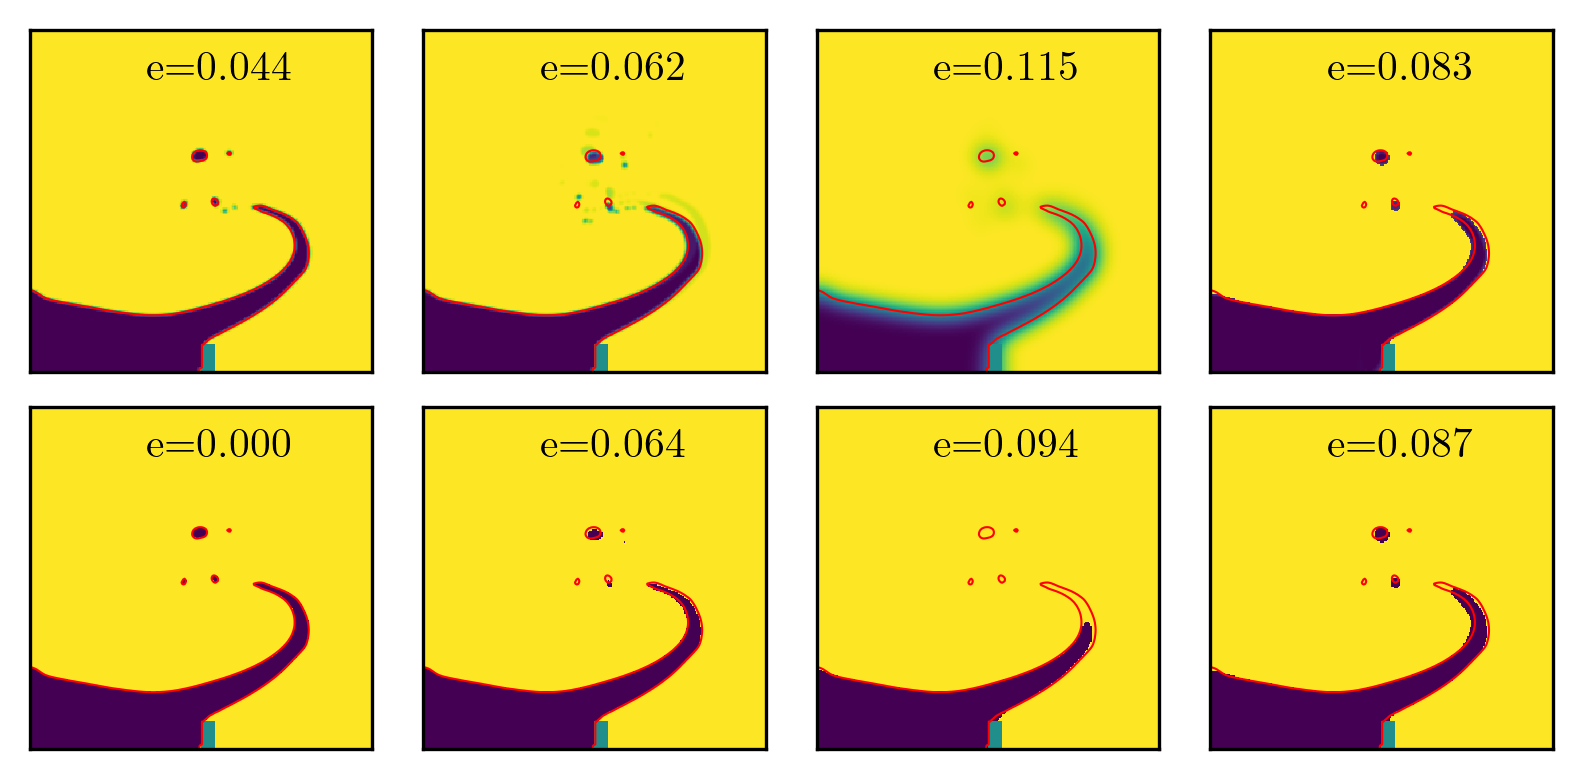

10


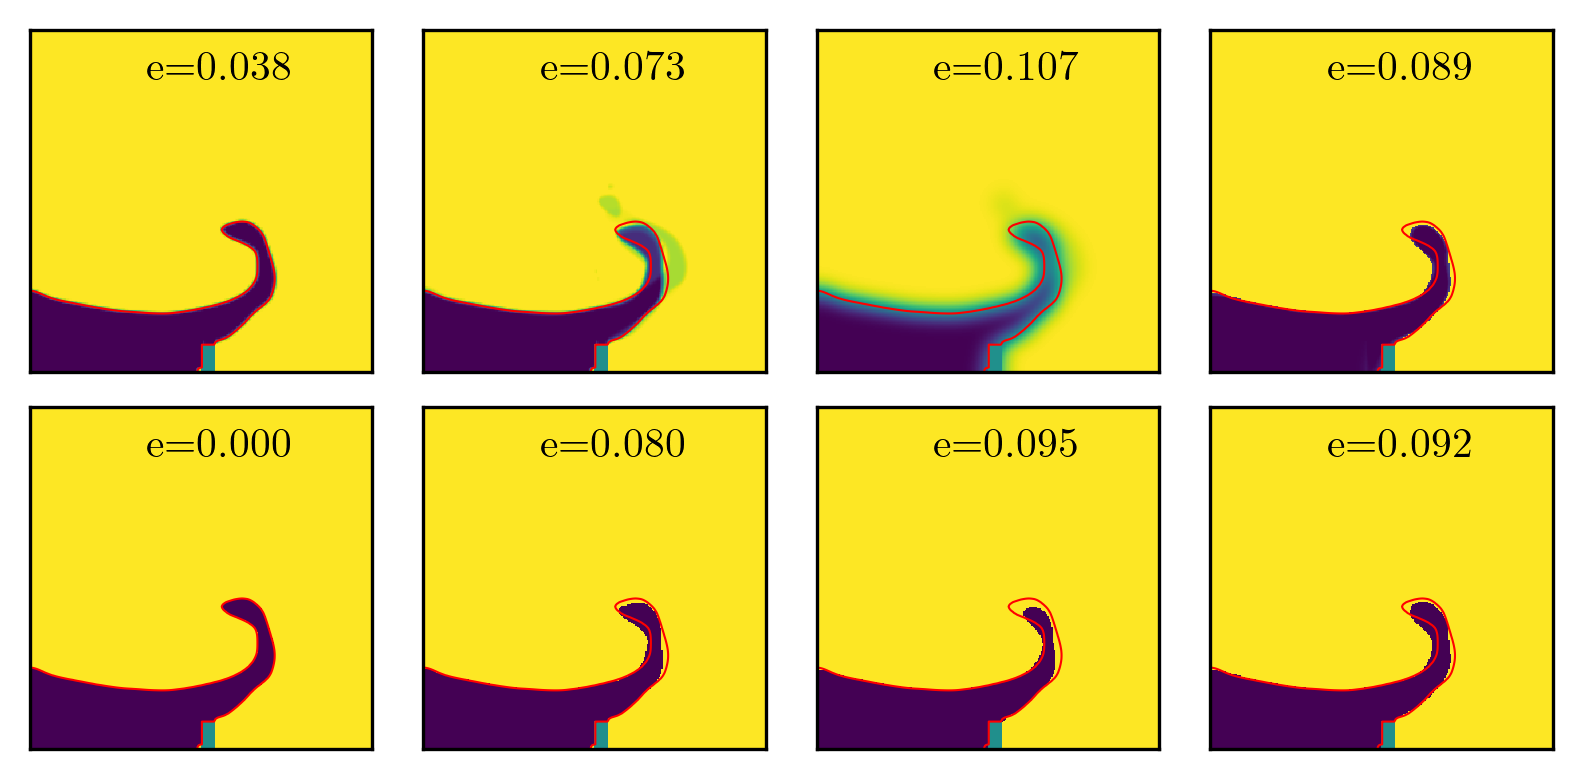

11


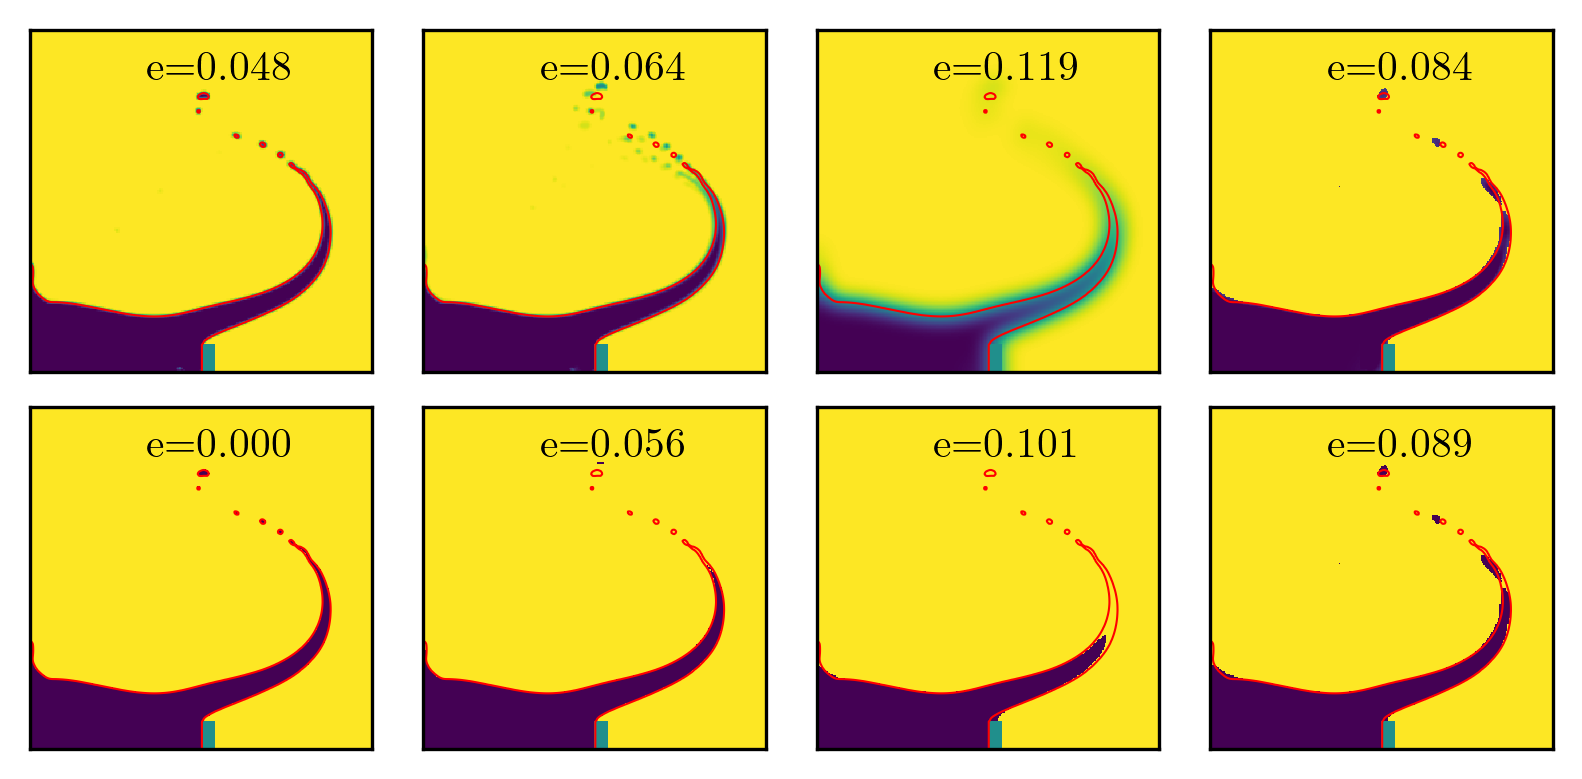

12


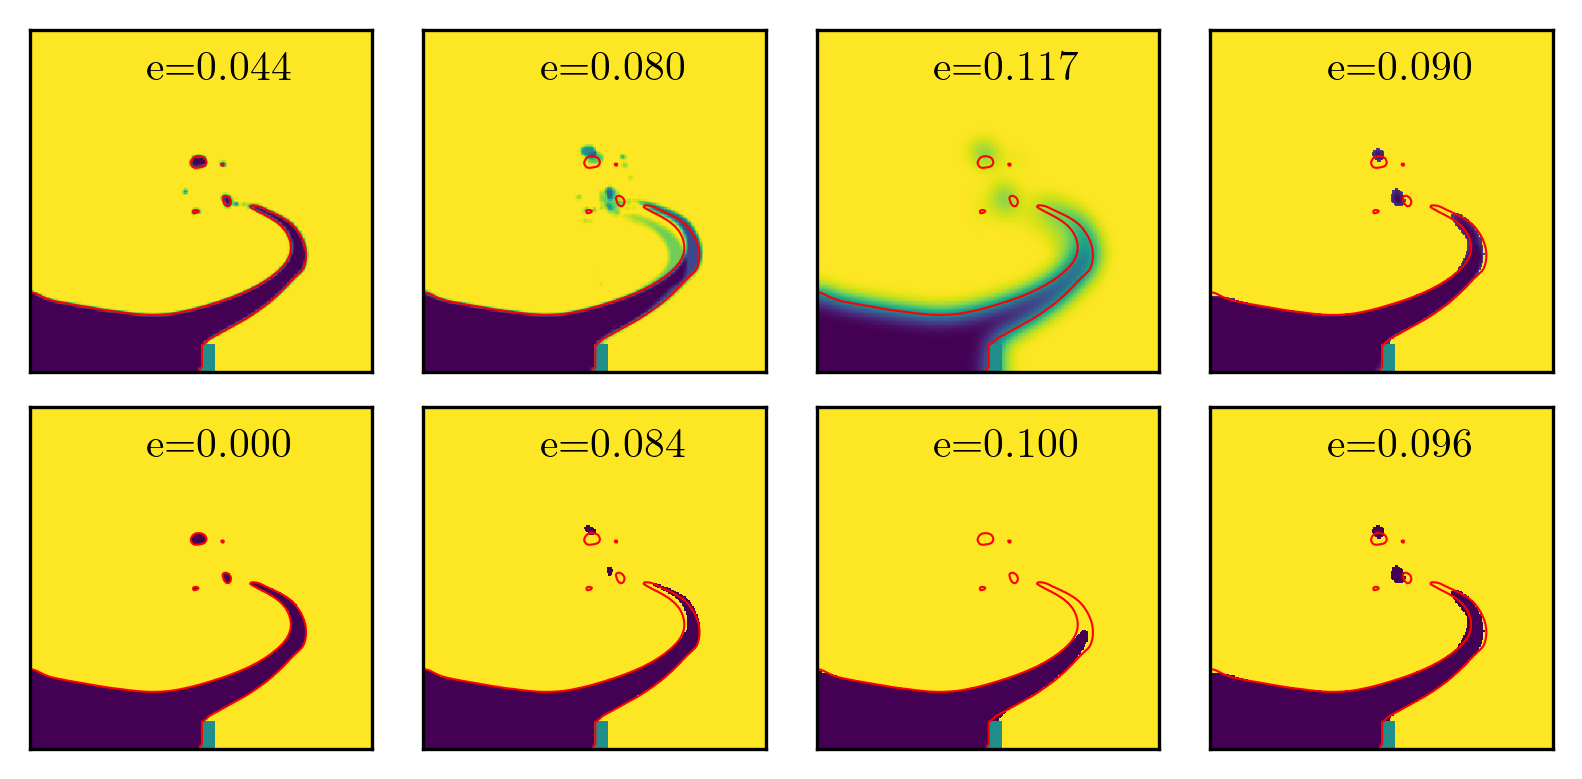

13


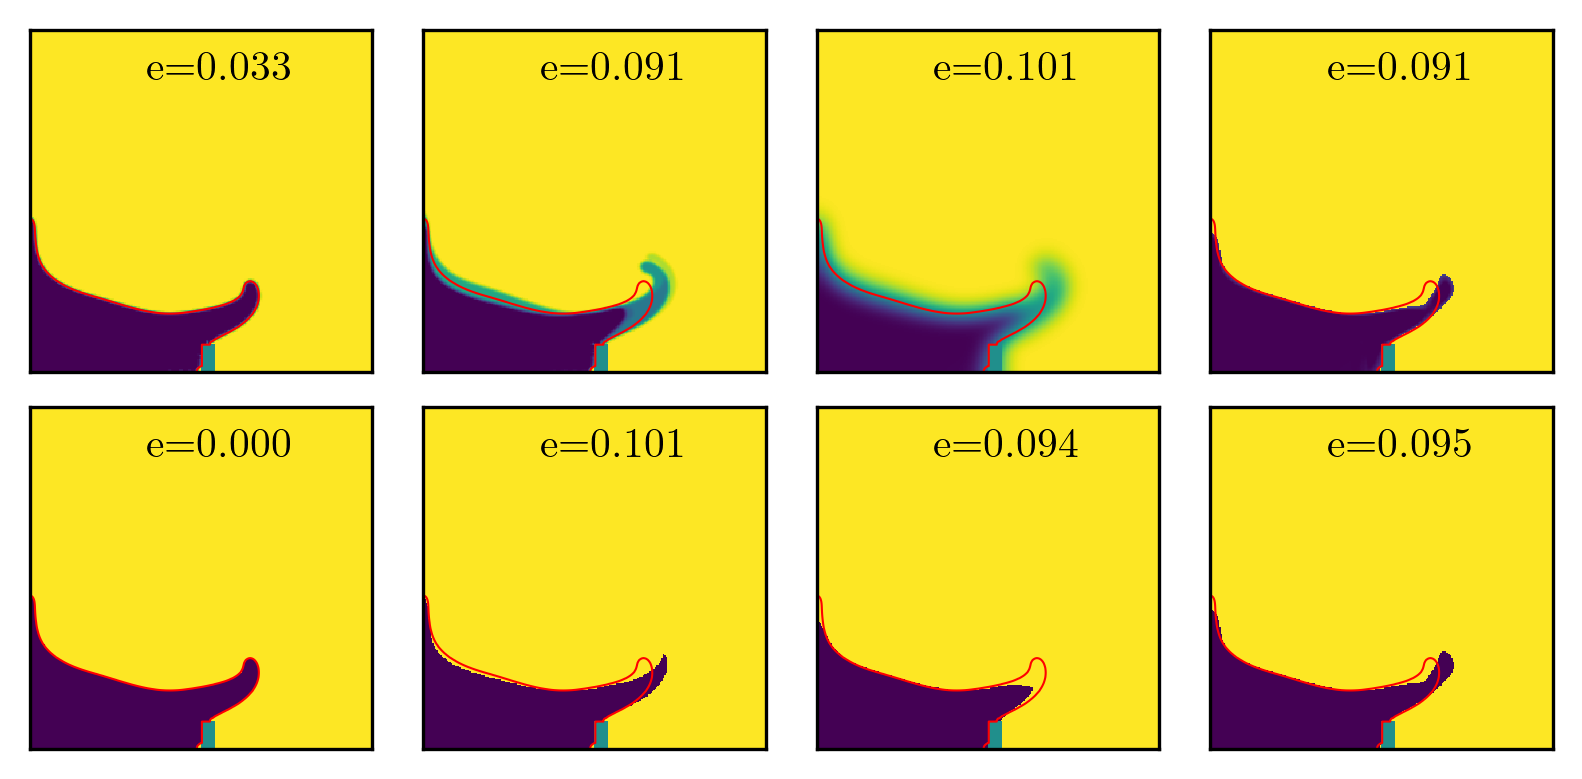

14


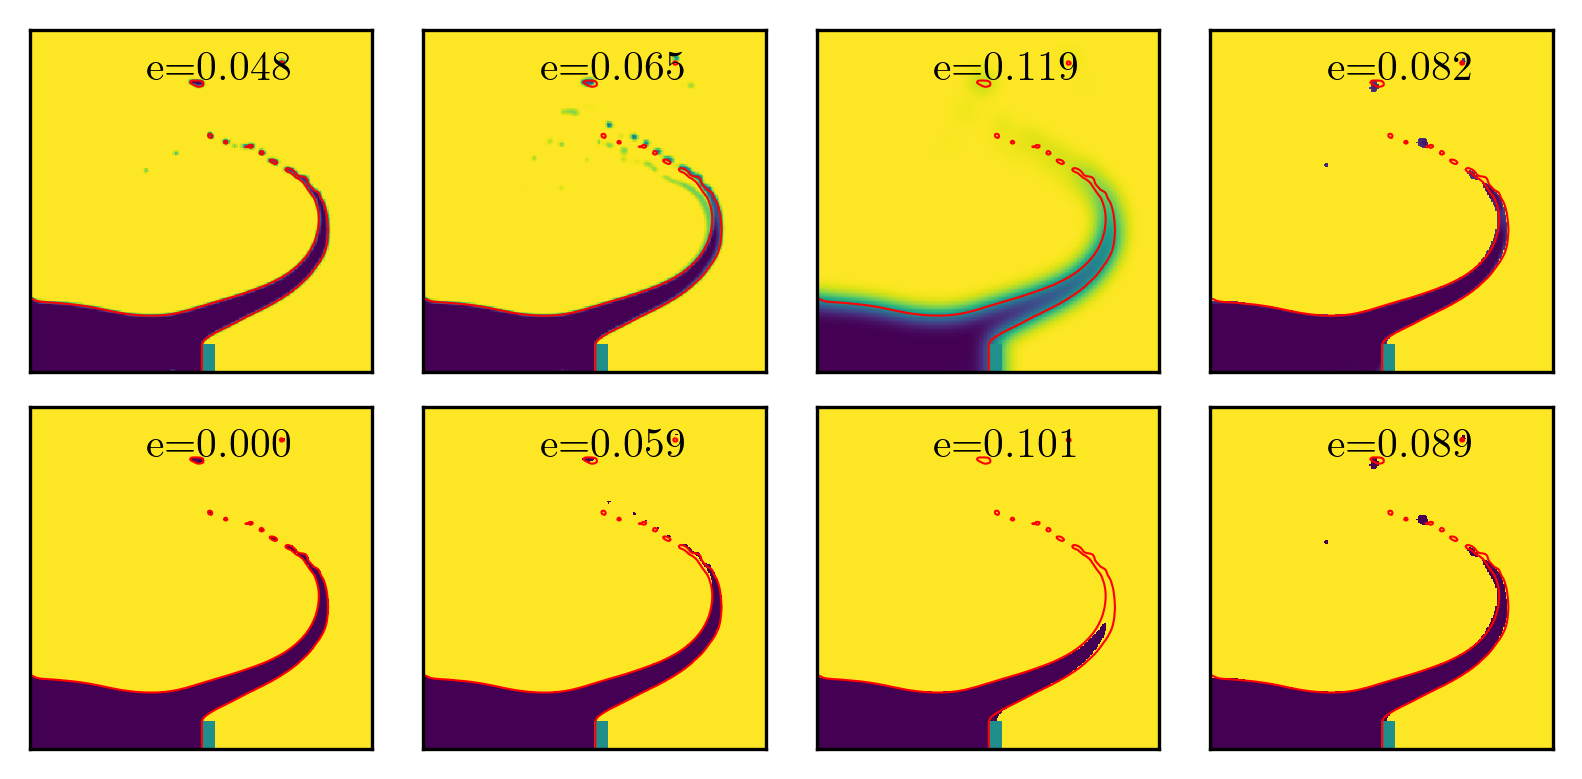

15


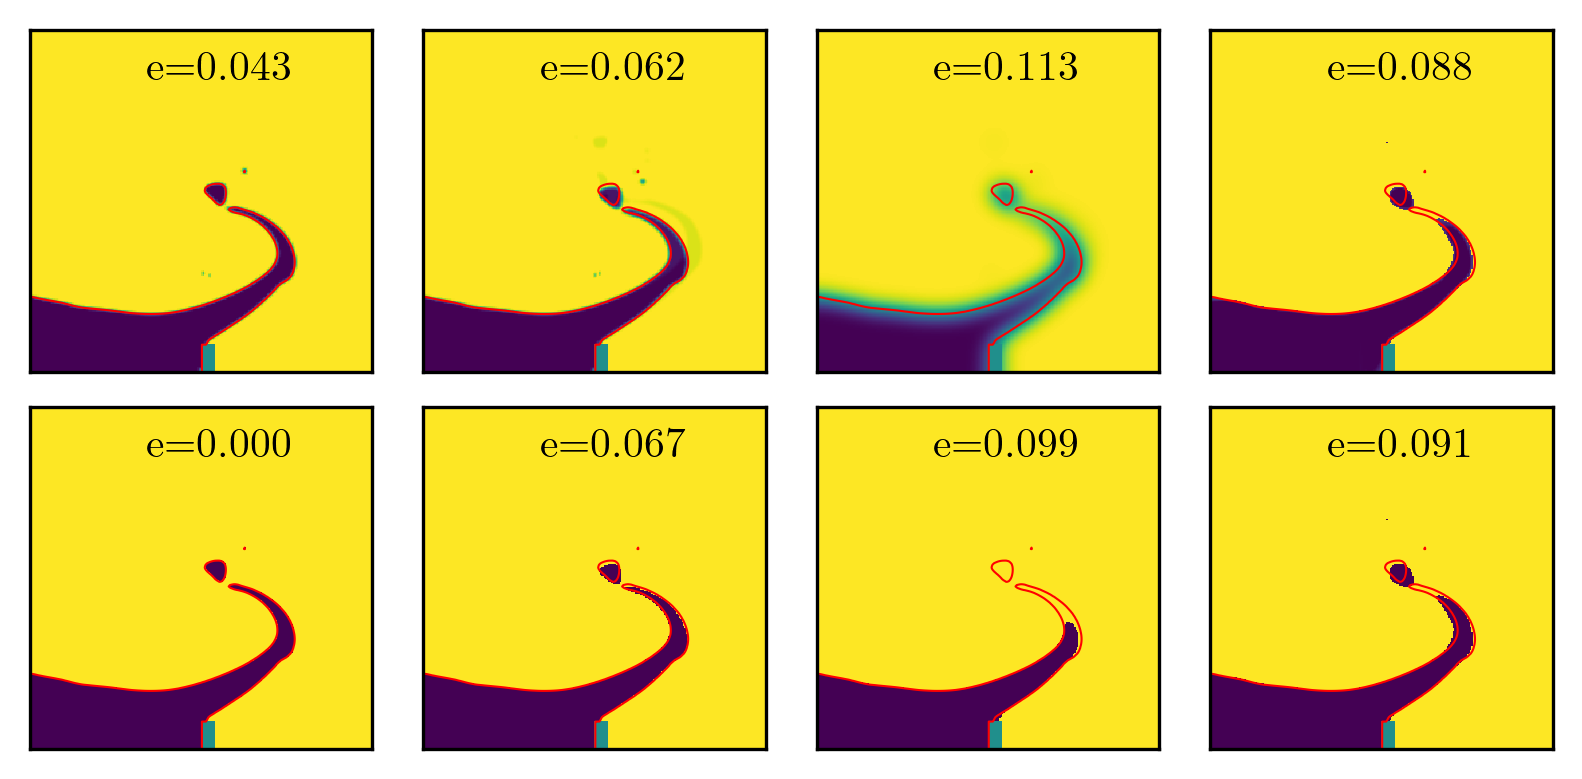

16


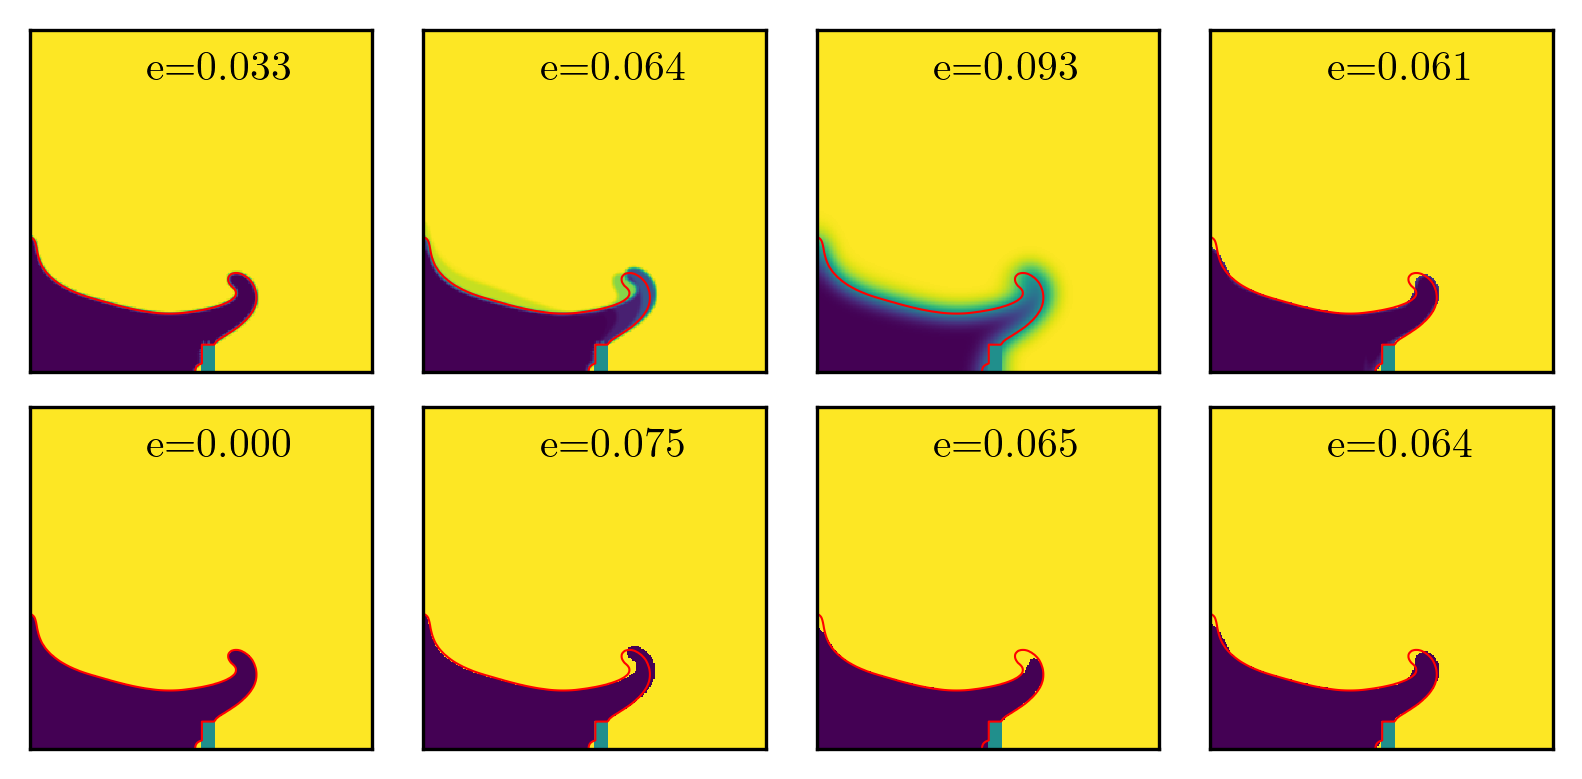

17


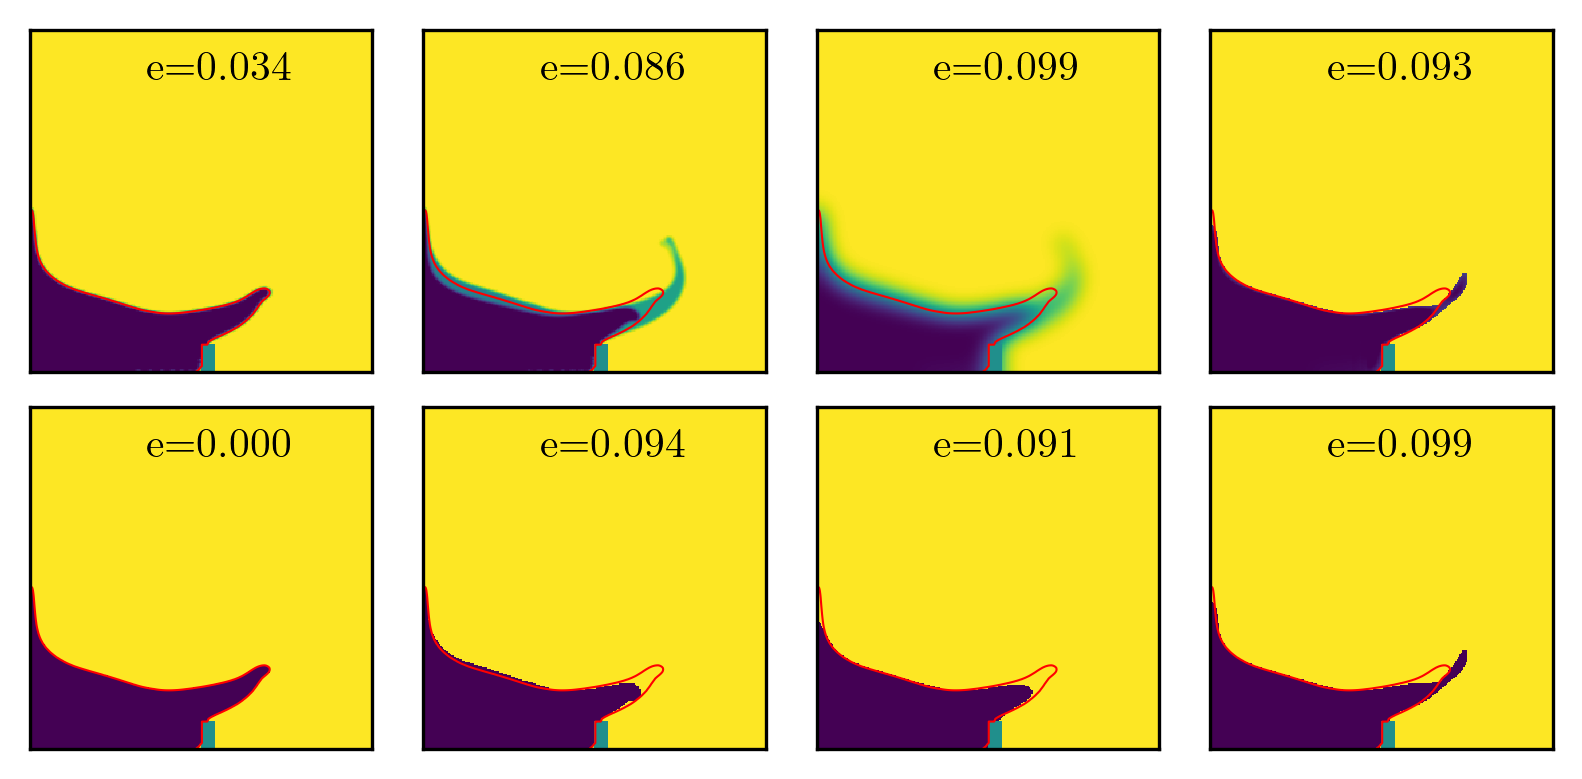

18


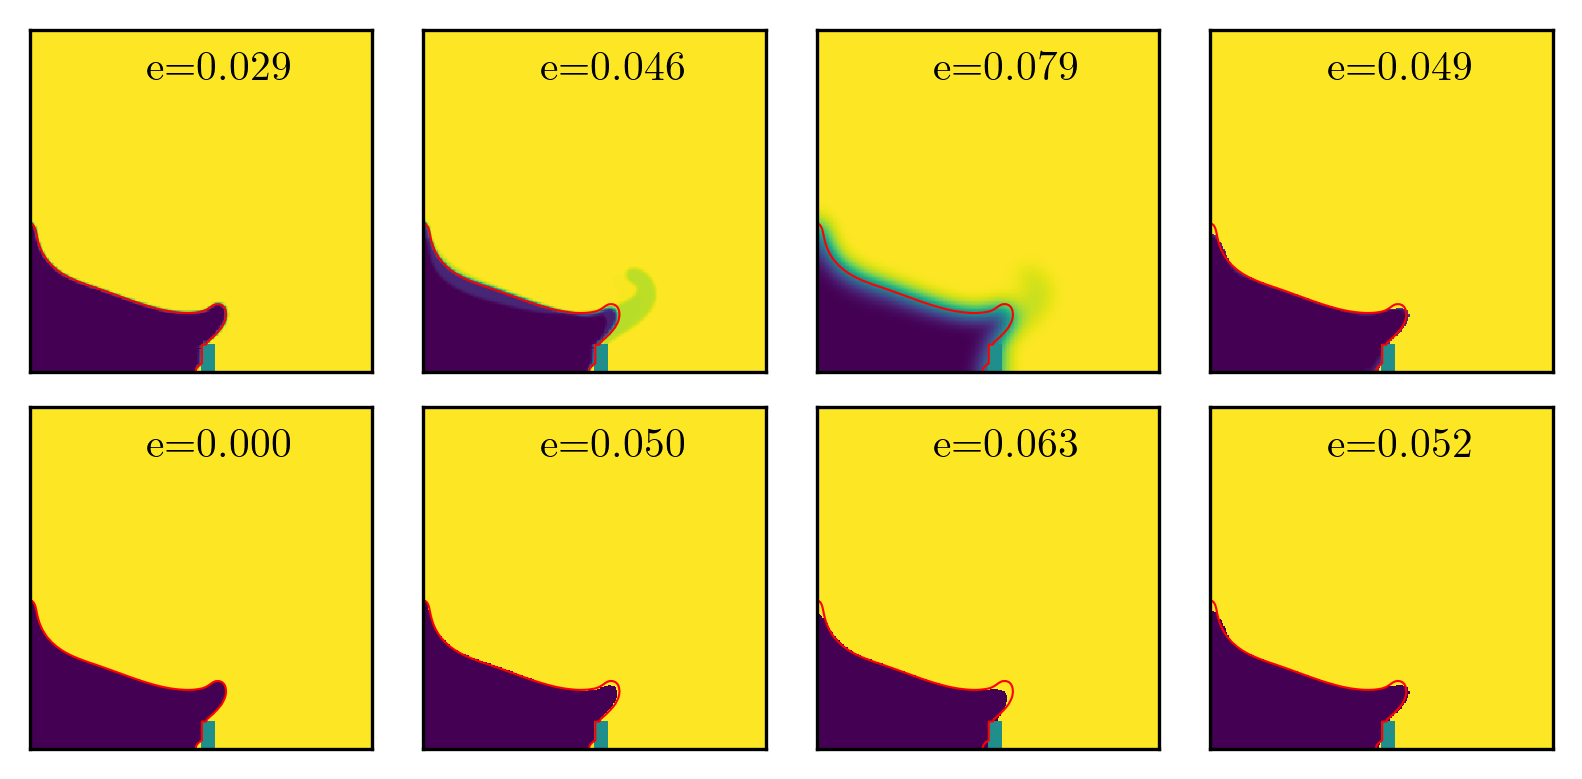

19


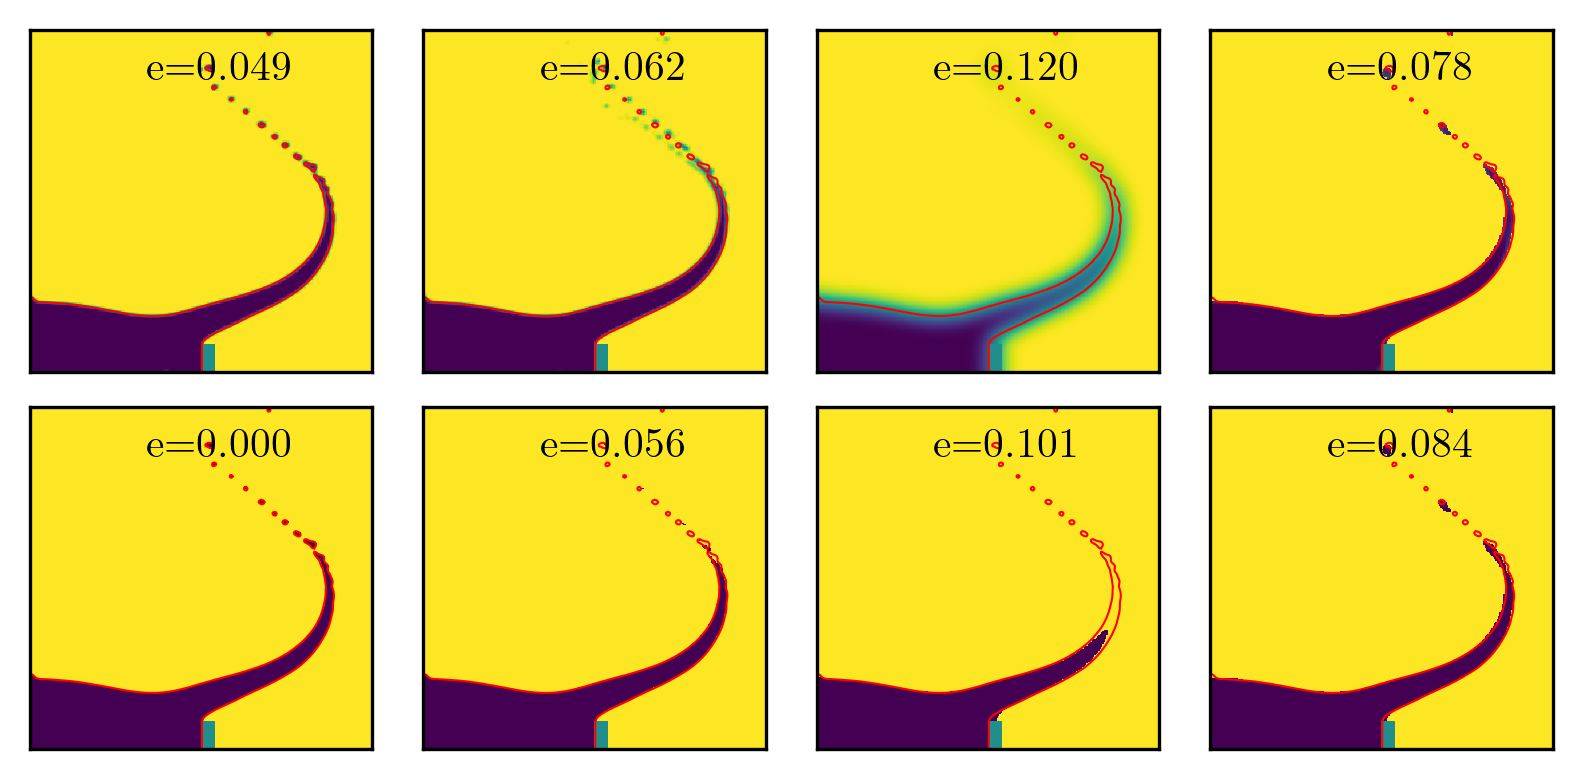

20


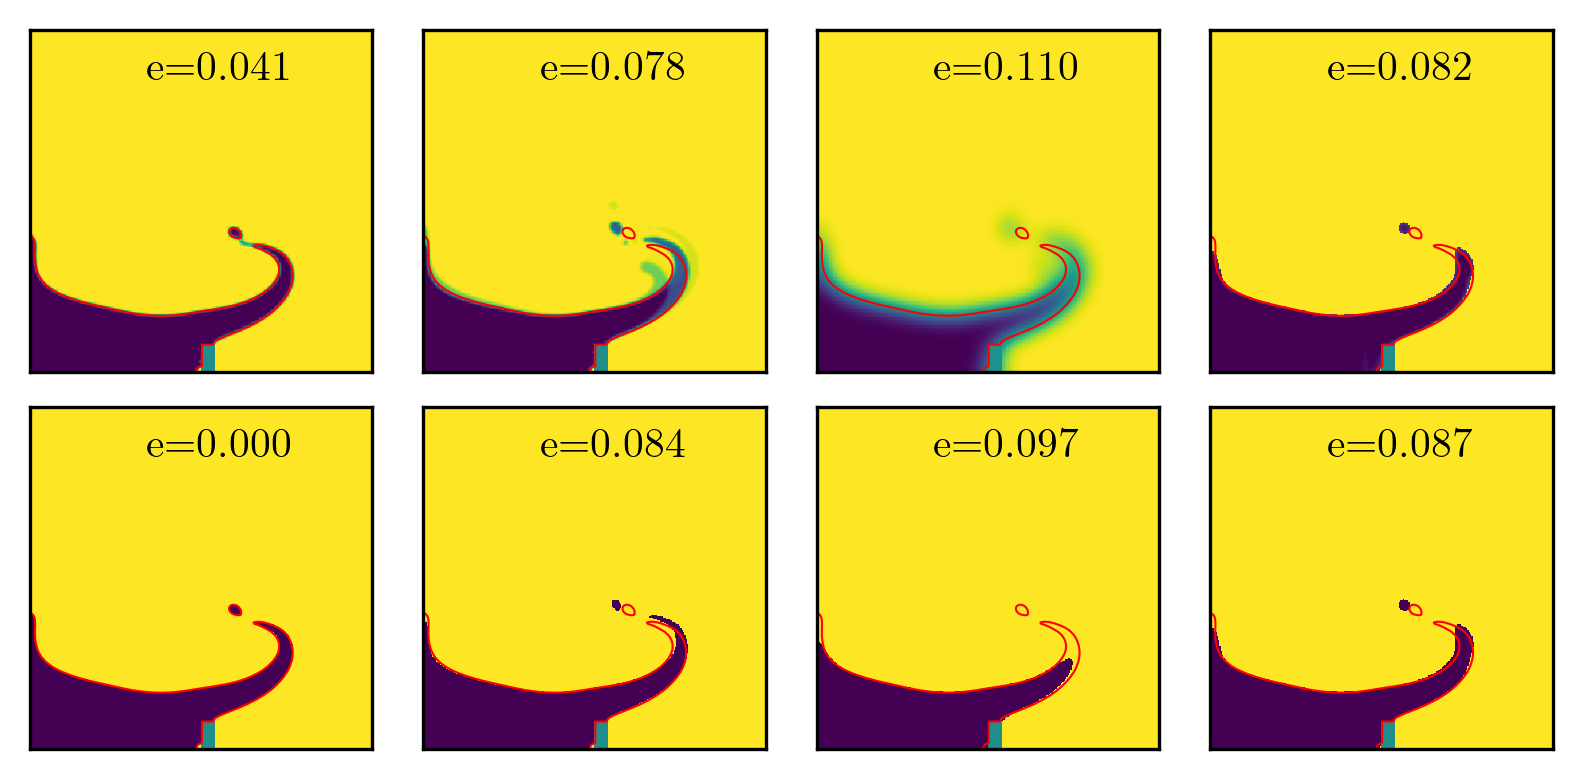

21


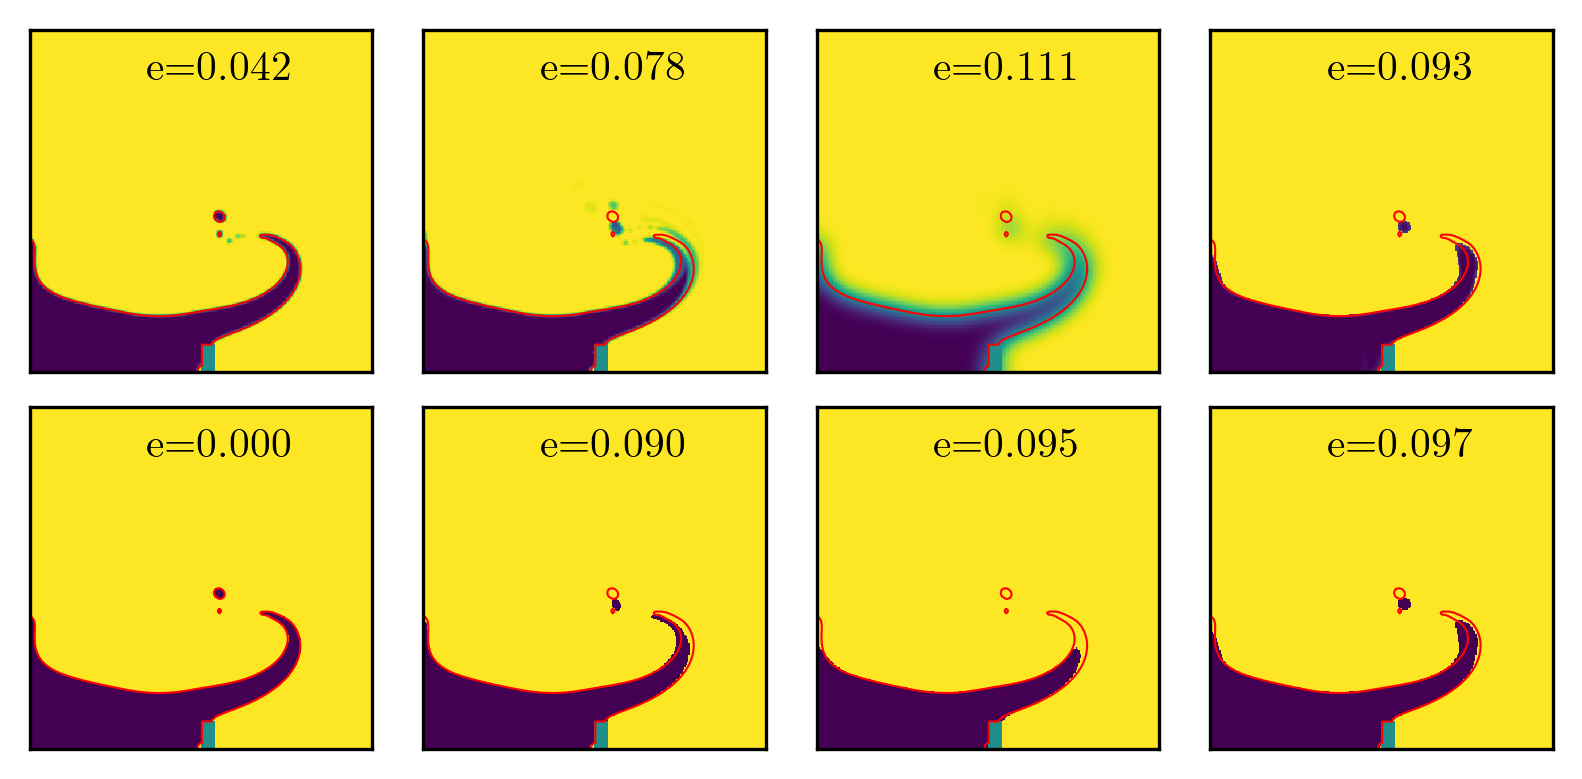

22


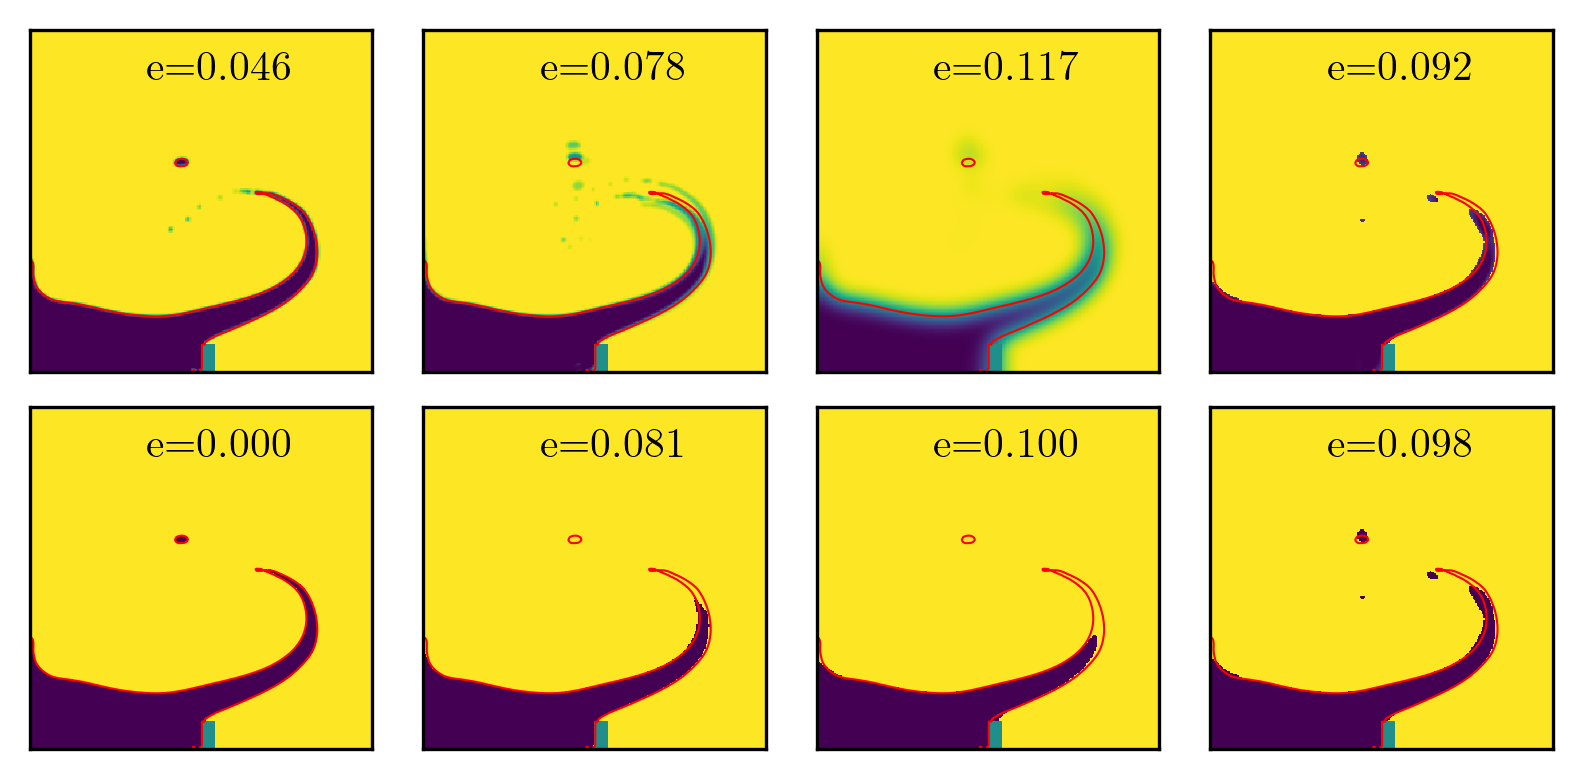

23


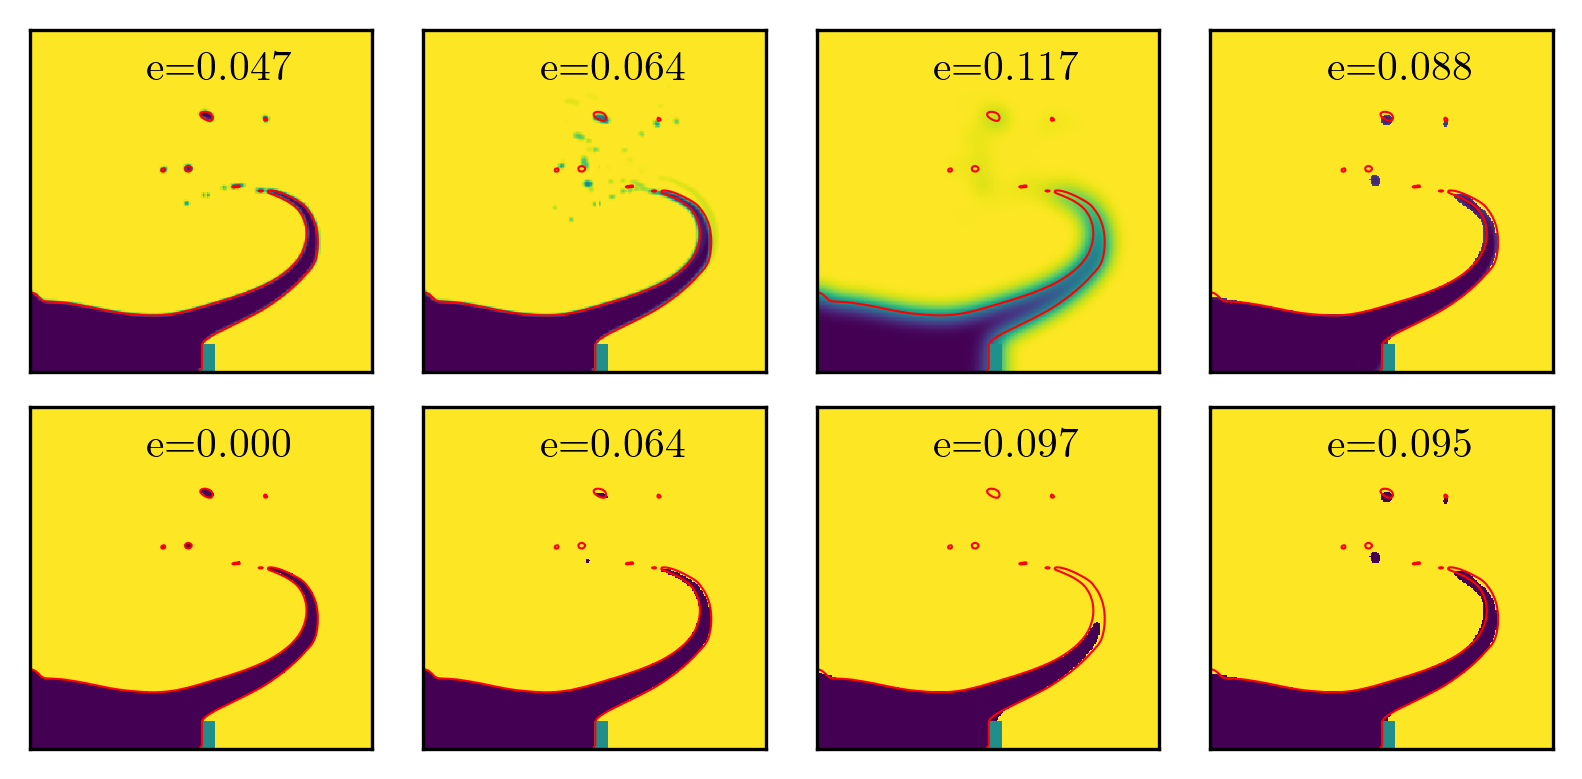

24


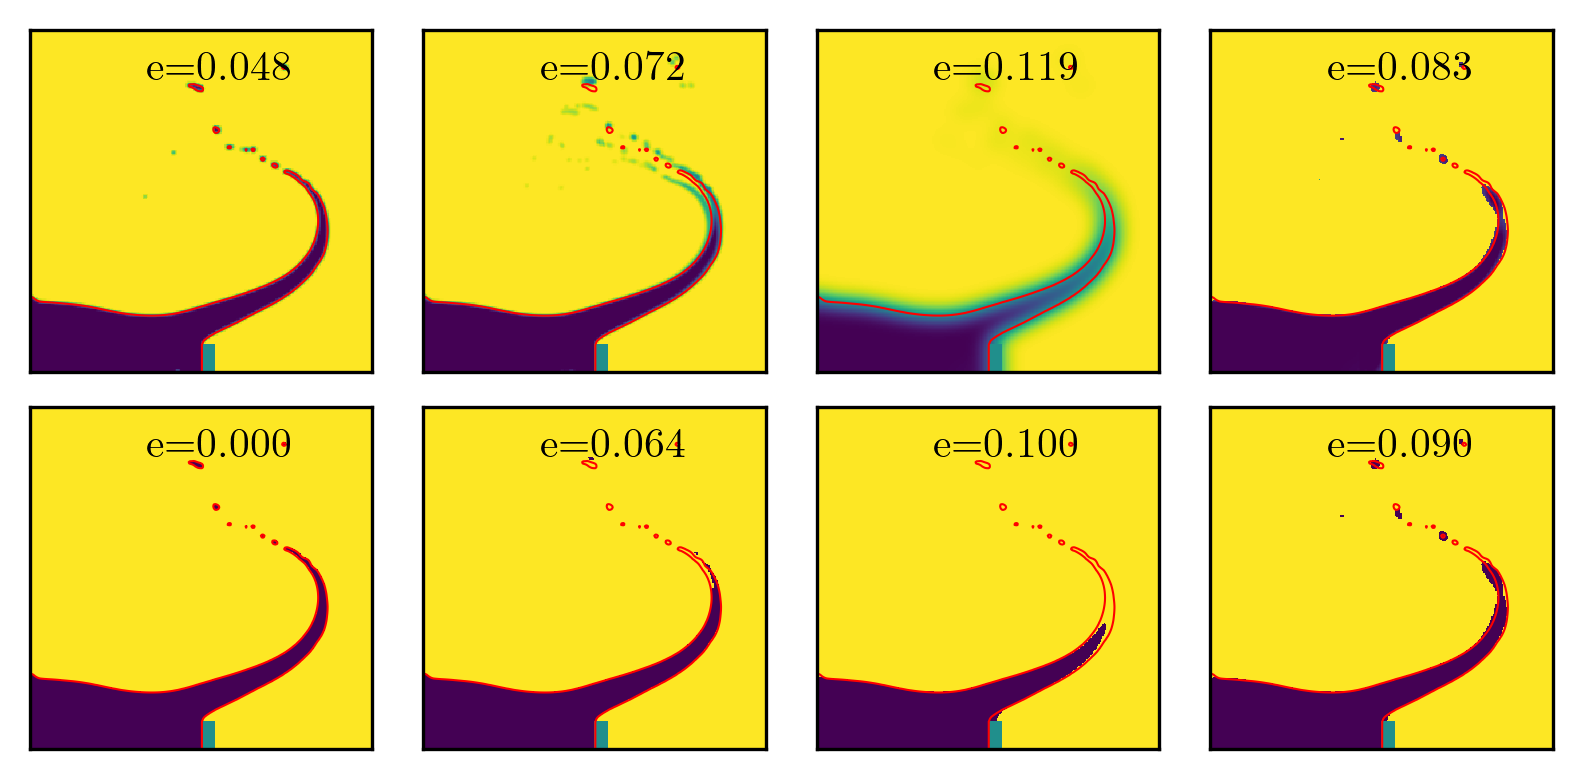

In [129]:
for j in range(25):
    print(j)
    exact_j = u_val_grid[:, j].reshape(n_x, n_y)
    ROM_j = u_ROM[:, j].reshape(n_x, n_y).copy()
    sROM_j = u_sROM[:, j].reshape(n_x, n_y).copy()

    sROM_j[is_wall] = 0.0
    sROMs_j = local_mass_conservation(sROM_j, 41, 250)
    sROM_j[is_wall] = 0.5
    sROMs_j[is_wall] = 0.5

    exactT_j = threshold(exact_j)
    ROMT_j = threshold(ROM_j)
    sROMT_j = threshold(sROM_j)
    sROMsT_j = threshold(sROMs_j)
    exactT_j[is_wall] = 0.5
    ROMT_j[is_wall] = 0.5
    sROMT_j[is_wall] = 0.5
    sROMsT_j[is_wall] = 0.5


    solutions = [exact_j, ROM_j, sROM_j, sROMs_j, exactT_j, ROMT_j, sROMT_j, sROMsT_j]


    fig, axs = plt.subplots(2, 4, figsize=(page_width_in, page_width_in/2))


    for sol, ax in zip(solutions, axs.ravel()):
        cs = plot_dam_snapshot(ax, sol, X, Y)
        ax.text(0.2, 0.5, "e={:.3f}".format(np.mean((sol-exactT_j)**2)**.5))
        ax.contour(X, Y, exact_j, levels=[0.5], linewidths=[0.5], colors=["r"])

    for ax in axs.ravel():

        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()

In [ ]:
truth_sol = u_val_grid[:, j].reshape(n_x, n_y)
truth_sol_thr = threshold(truth_sol)
truth_sol_thr[is_wall] = 0.5
truth = truth_sol_thr

In [ ]:
ss1 = u_sROM[:, j].reshape(n_x, n_y).copy()
ss1[is_wall] = 0.0
ss2 = local_mass_conservation(ss1, 21, 1000)
ss3 = local_mass_conservation(ss1, 31, 1000)
ss4 = local_mass_conservation(ss1, 41, 1000)
ss1 = threshold(ss1)
ss2 = threshold(ss2)
ss3 = threshold(ss3)
ss4 = threshold(ss4)
ss1[is_wall] = 0.5
ss2[is_wall] = 0.5
ss3[is_wall] = 0.5
ss4[is_wall] = 0.5


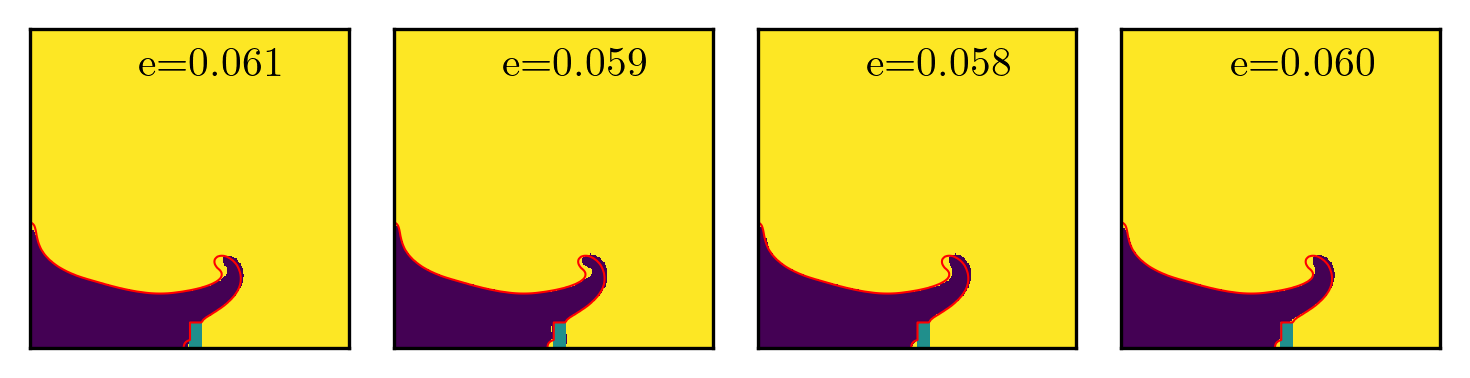

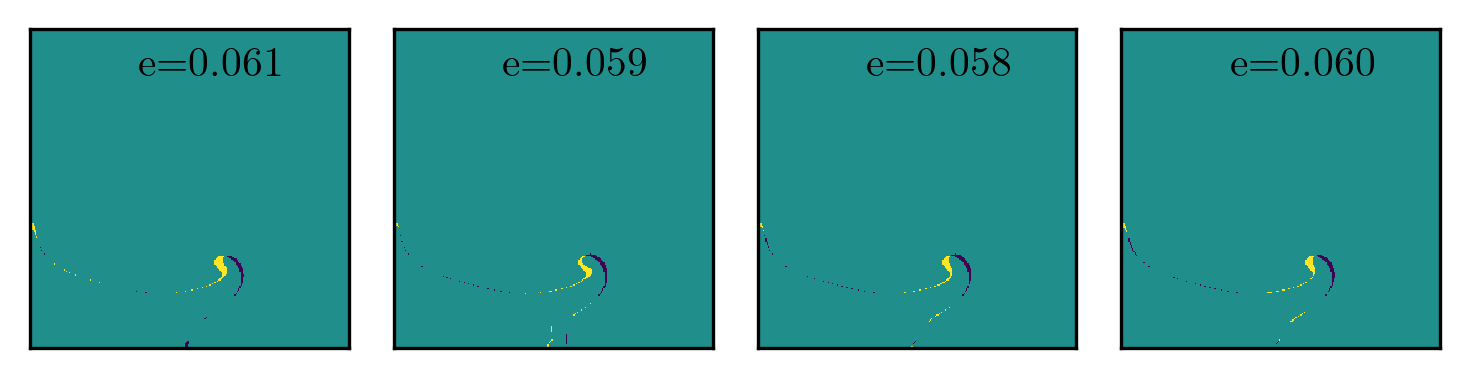

In [79]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(5, 15))
cs1 = plot_dam_snapshot(ax1, ss1, X, Y)
cs2 = plot_dam_snapshot(ax2, ss2, X, Y)
cs3 = plot_dam_snapshot(ax3, ss3, X, Y)
cs4 = plot_dam_snapshot(ax4, ss4, X, Y)

ax1.contour(X, Y, u_val_grid[:, j].reshape(n_x, n_y), levels=[0.5], linewidths=[0.5], colors=["r"])
ax2.contour(X, Y, u_val_grid[:, j].reshape(n_x, n_y), levels=[0.5], linewidths=[0.5], colors=["r"])
ax3.contour(X, Y, u_val_grid[:, j].reshape(n_x, n_y), levels=[0.5], linewidths=[0.5], colors=["r"])
ax4.contour(X, Y, u_val_grid[:, j].reshape(n_x, n_y), levels=[0.5], linewidths=[0.5], colors=["r"])


ax1.text(0.2, 0.5, "e={:.3f}".format(np.mean((ss1-truth)**2)**.5))
ax2.text(0.2, 0.5, "e={:.3f}".format(np.mean((ss2-truth)**2)**.5))
ax3.text(0.2, 0.5, "e={:.3f}".format(np.mean((ss3-truth)**2)**.5))
ax4.text(0.2, 0.5, "e={:.3f}".format(np.mean((ss4-truth)**2)**.5))

for ax, cs in zip([ax1, ax2, ax3, ax4], [cs1, cs2, cs3, cs4]):
    ax.set_xticks([])
    ax.set_yticks([])
    #divider = make_axes_locatable(ax)
    #cax = divider.append_axes("right", size="5%", pad=0.05)
    #fig.colorbar(cs, cax=cax)
plt.show()


fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(5, 15))
cs1 = plot_dam_snapshot(ax1, ss1-truth, X, Y, vmin=-1, vmax=1)
cs2 = plot_dam_snapshot(ax2, ss2-truth, X, Y, vmin=-1, vmax=1)
cs3 = plot_dam_snapshot(ax3, ss3-truth, X, Y, vmin=-1, vmax=1)
cs4 = plot_dam_snapshot(ax4, ss4-truth, X, Y, vmin=-1, vmax=1)

ax1.text(0.2, 0.5, "e={:.3f}".format(np.mean((ss1-truth)**2)**.5))
ax2.text(0.2, 0.5, "e={:.3f}".format(np.mean((ss2-truth)**2)**.5))
ax3.text(0.2, 0.5, "e={:.3f}".format(np.mean((ss3-truth)**2)**.5))
ax4.text(0.2, 0.5, "e={:.3f}".format(np.mean((ss4-truth)**2)**.5))

for ax, cs in zip([ax1, ax2, ax3, ax4], [cs1, cs2, cs3, cs4]):
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

1.0
1.0
1.000000000000042
1.0


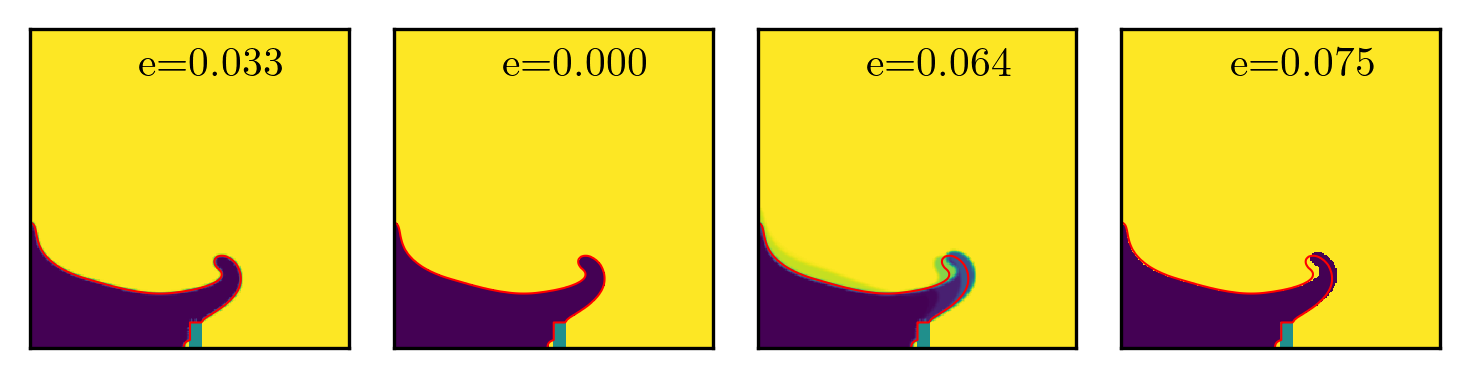

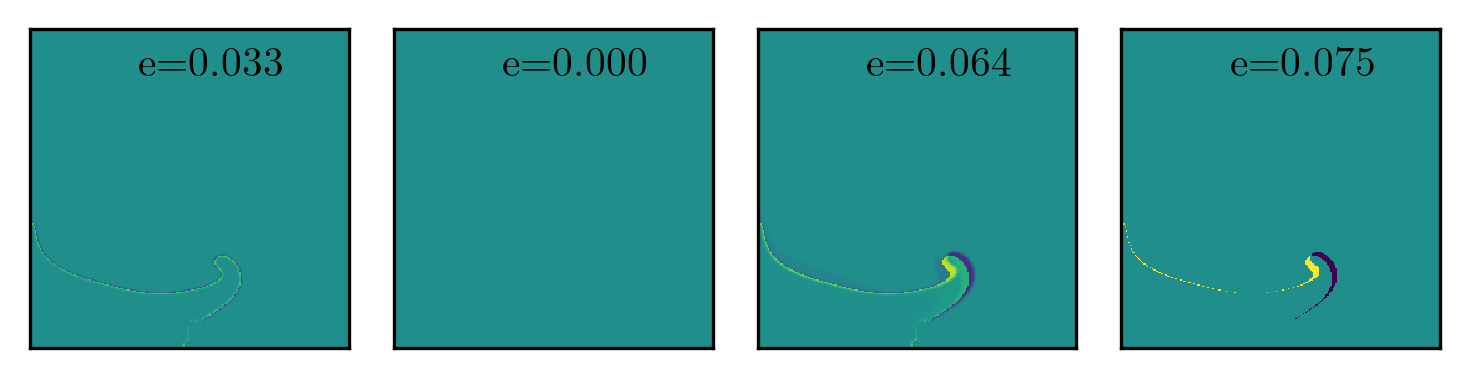

In [80]:
ss1 = u_val_grid[:, j].reshape(n_x, n_y)
ss2 = threshold(ss1)
ss2[is_wall] = 0.5
ss3 = u_ROM[:, j].reshape(n_x, n_y)
ss4 = threshold(ss3)
ss4[is_wall] = 0.5

print(np.max(ss1))
print(np.max(ss2))
print(np.max(ss3))
print(np.max(ss4))

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(5, 15))
cs1 = plot_dam_snapshot(ax1, ss1, X, Y)
cs2 = plot_dam_snapshot(ax2, ss2, X, Y)
cs3 = plot_dam_snapshot(ax3, ss3, X, Y)
cs4 = plot_dam_snapshot(ax4, ss4, X, Y)

ax1.contour(X, Y, u_val_grid[:, j].reshape(n_x, n_y), levels=[0.5], linewidths=[0.5], colors=["r"])
ax2.contour(X, Y, u_val_grid[:, j].reshape(n_x, n_y), levels=[0.5], linewidths=[0.5], colors=["r"])
ax3.contour(X, Y, u_val_grid[:, j].reshape(n_x, n_y), levels=[0.5], linewidths=[0.5], colors=["r"])
ax4.contour(X, Y, u_val_grid[:, j].reshape(n_x, n_y), levels=[0.5], linewidths=[0.5], colors=["r"])

ax1.text(0.2, 0.5, "e={:.3f}".format(np.mean((ss1-truth)**2)**.5))
ax2.text(0.2, 0.5, "e={:.3f}".format(np.mean((ss2-truth)**2)**.5))
ax3.text(0.2, 0.5, "e={:.3f}".format(np.mean((ss3-truth)**2)**.5))
ax4.text(0.2, 0.5, "e={:.3f}".format(np.mean((ss4-truth)**2)**.5))

for ax, cs in zip([ax1, ax2, ax3, ax4], [cs1, cs2, cs3, cs4]):
    ax.set_xticks([])
    ax.set_yticks([])
    #divider = make_axes_locatable(ax)
    #cax = divider.append_axes("right", size="5%", pad=0.05)
    #fig.colorbar(cs, cax=cax)
plt.show()


fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(5, 15))
cs1 = plot_dam_snapshot(ax1, ss1-truth, X, Y, vmin=-1, vmax=1)
cs2 = plot_dam_snapshot(ax2, ss2-truth, X, Y, vmin=-1, vmax=1)
cs3 = plot_dam_snapshot(ax3, ss3-truth, X, Y, vmin=-1, vmax=1)
cs4 = plot_dam_snapshot(ax4, ss4-truth, X, Y, vmin=-1, vmax=1)

ax1.text(0.2, 0.5, "e={:.3f}".format(np.mean((ss1-truth)**2)**.5))
ax2.text(0.2, 0.5, "e={:.3f}".format(np.mean((ss2-truth)**2)**.5))
ax3.text(0.2, 0.5, "e={:.3f}".format(np.mean((ss3-truth)**2)**.5))
ax4.text(0.2, 0.5, "e={:.3f}".format(np.mean((ss4-truth)**2)**.5))

for ax, cs in zip([ax1, ax2, ax3, ax4], [cs1, cs2, cs3, cs4]):
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

In [81]:
58/75

0.7733333333333333